<div style="padding:30px 32px;border-radius:24px;background:linear-gradient(125deg,#102a43,#0f766e 52%,#f59e0b);color:white;box-shadow:0 16px 40px rgba(15,118,110,.25)">
  <div style="font-size:14px;letter-spacing:.16em;text-transform:uppercase;opacity:.86">Kaggriculture • Public Replay Distillation • Executed Submission</div>
  <h1 style="margin:.35em 0 .18em;font-size:43px;line-height:1.06">The 720-Turn Farm Tape</h1>
  <p style="font-size:19px;max-width:940px;margin:0;opacity:.96">Version 19 turns a public top-four trajectory into a compact policy that survives broad and leader-family stress—then stress-tests it across seeds, opponents, and both seats.</p>
</div>

## What this notebook contributes

- the exact, standalone `main.py` and `submission.tar.gz`;
- a visual teardown of the farm's capital curve, crop rotation, herd, labor, geometry, and market actions;
- a broad untouched-seed cross-play gate against public and campaign controls;
- a direct falsification of the tempting **all-melons** strategy;
- an unusually simple starter: return the action scheduled for `obs.step`.

**Provenance first.** The action sequence was distilled from public episode **89454731**, played by [Kaito Fukami](https://www.kaggle.com/kaitofukami) against **venks**. The public replay scored **125,364 vs 128,733**. This notebook does **not** claim the player's private source or strategy authorship. Kaggle's [competition rules](https://www.kaggle.com/competitions/kaggriculture/rules) state that replays, including actions, may be made publicly available and downloadable.

> Cross-play below is local evidence from the official simulator. It is not a public leaderboard score; only a completed Kaggle submission can establish that.


In [1]:
import hashlib, importlib.metadata, json, subprocess, sys, tarfile, warnings
from pathlib import Path

from IPython import get_ipython
shell = get_ipython()
if shell is not None:
    shell.run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
COLORS = ["#0f766e", "#f59e0b", "#2563eb", "#7c3aed", "#dc2626", "#0891b2", "#64748b"]

required = (1, 32, 2)
try:
    installed_text = importlib.metadata.version("kaggle-environments")
    installed = tuple(int(x) for x in installed_text.split(".")[:3])
except Exception:
    installed_text, installed = "missing", (0, 0, 0)
if installed < required:
    print(f"Upgrading kaggle-environments {installed_text} -> 1.32.2")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "--no-deps", "kaggle-environments==1.32.2"],
        check=True,
    )
import kaggle_environments
from kaggle_environments import make
assert tuple(int(x) for x in kaggle_environments.__version__.split(".")[:3]) >= required
print("kaggle-environments", kaggle_environments.__version__)


Upgrading kaggle-environments 1.29.3 -> 1.32.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 24.8 MB/s eta 0:00:00


OpenSpiel exception: Unknown game 'capture_the_flag'. Available games are:
2048
add_noise
amazons
amazons_proxy
ant_foraging_arena
antichess
backgammon
backgammon_proxy
banqi
bargaining
bargaining_proxy
battleship
blackjack
blotto
breakthrough
bridge
bridge_arena
bridge_uncontested_bidding
cached_tree
catch
checkers
chess
chinese_checkers
cliff_walking
clobber
clobber_proxy
coin_game
coin_game_arena
colored_trails
connect_four
coop_box_pushing
coop_to_1p
coordinated_mp
crazy_eights
crazyhouse
cribbage
cursor_go
dark_chess
dark_hex
dark_hex_ir
deep_sea
dots_and_boxes
dots_and_boxes_proxy
dou_dizhu
efg_game
einstein_wurfelt_nicht
euchre
first_sealed_auction
gin_rummy
gin_rummy_proxy
go
gomoku
goofspiel
hanabi
havannah
havannah_proxy
hearts
hex
hive
kriegspiel
kuhn_poker
laser_tag
latent_ttt
leduc_poker
lewis_signaling
liars_dice
liars_dice_ir
lines_of_action
lines_of_action_proxy
maedn
mancala
mancala_proxy
markov_soccer
matching_pennies_3p
matrix_bos
matrix_brps
matrix_cd
matrix_coordin

[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 40.
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: OpenSpiel games skipped: 1.
kaggle-environments 1.32.2


OpenSpiel exception: Unknown game 'capture_the_flag'. Available games are:
2048
add_noise
amazons
amazons_proxy
ant_foraging_arena
antichess
backgammon
backgammon_proxy
banqi
bargaining
bargaining_proxy
battleship
blackjack
blotto
breakthrough
breakthrough_proxy
bridge
bridge_arena
bridge_uncontested_bidding
cached_tree
catch
chat_game
checkers
checkers_proxy
chess
chinese_checkers
cliff_walking
clobber
clobber_proxy
coin_game
coin_game_arena
coin_game_proxy
colored_trails
connect_four
connect_four_proxy
coop_box_pushing
coop_to_1p
coordinated_mp
crazy_eights
crazyhouse
cribbage
cursor_go
dark_chess
dark_hex
dark_hex_ir
dark_hex_proxy
deep_sea
dots_and_boxes
dots_and_boxes_proxy
dou_dizhu
efg_game
einstein_wurfelt_nicht
euchre
first_sealed_auction
gin_rummy
gin_rummy_proxy
go
go_proxy
gomoku
goofspiel
hanabi
havannah
havannah_proxy
hearts
hex
hive
hive_proxy
kriegspiel
kuhn_poker
laser_tag
latent_ttt
leduc_poker
lewis_signaling
liars_dice
liars_dice_ir
lines_of_action
lines_of_action_p

## 1. Why a timed public-tape policy can work

Kaggriculture has stochastic weeds and shared prices, but the board geometry, 30-day clock, action cadence, and core growth rules are stable. A high-quality tape can therefore encode an entire capital schedule: buy productive assets early, unlock land on time, keep labor ahead of the job queue, and liquidate before the final bell. Invalid or unavailable commands degrade harmlessly while the rest of the day's parallel commands still execute.

Version 19 uses Kaito Fukami's side of public episode 89454731. That replay narrowly lost to rank-one venks, which makes it a useful lesson: source-game outcome and counterfactual robustness are different quantities. After freezing the tape, we tested it in both seats against broad public agents, current leader traces, and eight preserved ladder traces. Inference reads only `step`; it uses no replay files, internet, or hidden state. A causal turn-two cash router was also tested and rejected: it raised counter-family mean margin but reduced wins from 8/16 to 7/16.


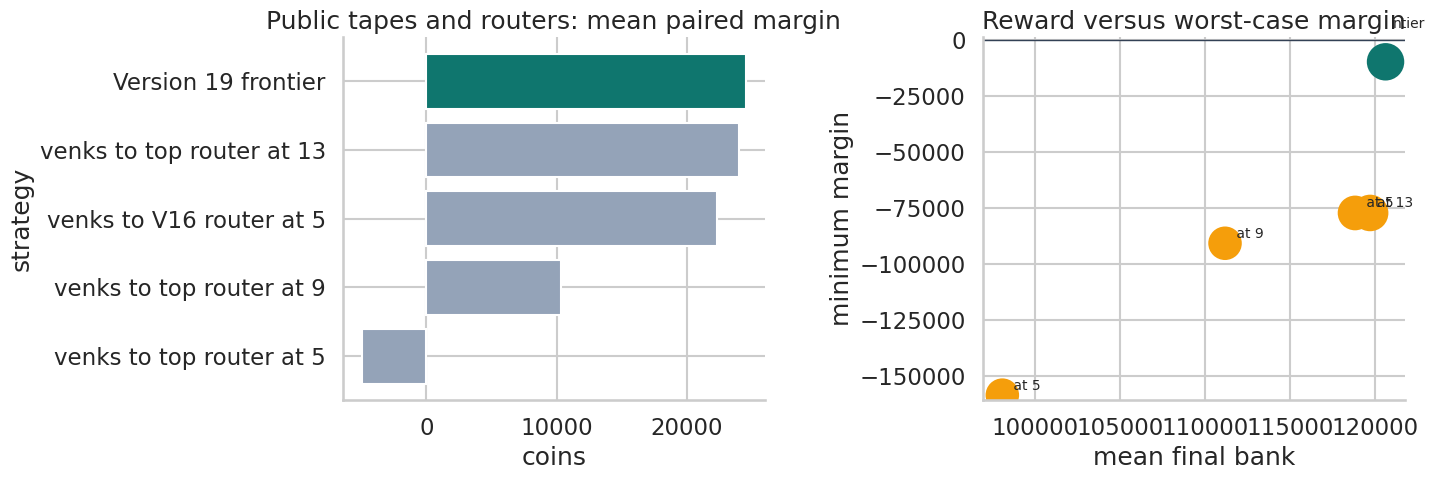

,challenger,games,wins,mean_money,mean_margin,min_margin,label,win_rate,episode
0,newtoptrace:89454731:0,80,71,120633.78,24516.64,-9897.0,Version 19 frontier,0.89,0
2,venkstop:13:8:6:89454746:0,80,67,119727.20,24045.16,-77217.0,venks to top router at 13,0.84,0
1,venkshybrid:5:8:1:664,80,59,118841.62,22292.28,-77217.0,venks to V16 router at 5,0.74,664
4,venkstop:9:8:6:89454746:0,80,54,111195.52,10359.39,-90715.0,venks to top router at 9,0.68,0
3,venkstop:5:8:1:89454746:0,80,54,98100.56,-4913.38,-158360.0,venks to top router at 5,0.68,0


In [2]:
SCREEN_SUMMARY_ROWS = [{'challenger': 'newtoptrace:89454731:0', 'games': 80, 'wins': 71, 'mean_money': 120633.775, 'mean_margin': 24516.6375, 'min_margin': -9897.0, 'label': 'Kaito 89454731'}, {'challenger': 'venkshybrid:5:8:1:664', 'games': 80, 'wins': 59, 'mean_money': 118841.625, 'mean_margin': 22292.275, 'min_margin': -77217.0, 'label': 'venks to V16 router at 5'}, {'challenger': 'venkstop:13:8:6:89454746:0', 'games': 80, 'wins': 67, 'mean_money': 119727.2, 'mean_margin': 24045.1625, 'min_margin': -77217.0, 'label': 'venks to top router at 13'}, {'challenger': 'venkstop:5:8:1:89454746:0', 'games': 80, 'wins': 54, 'mean_money': 98100.5625, 'mean_margin': -4913.375, 'min_margin': -158360.0, 'label': 'venks to top router at 5'}, {'challenger': 'venkstop:9:8:6:89454746:0', 'games': 80, 'wins': 54, 'mean_money': 111195.525, 'mean_margin': 10359.3875, 'min_margin': -90715.0, 'label': 'venks to top router at 9'}]
candidate_summary = pd.DataFrame(SCREEN_SUMMARY_ROWS)
candidate_summary["win_rate"] = candidate_summary.wins / candidate_summary.games
candidate_summary["episode"] = candidate_summary.challenger.str.split(":").str[-1]
candidate_summary.loc[candidate_summary.challenger == "radianttrace_router_v13", "label"] = "Version 13 router"
candidate_summary.loc[candidate_summary.challenger == "radianttrace_router_v14", "label"] = "Version 14 router"
candidate_summary.loc[candidate_summary.challenger == "radianttrace_router_v15", "label"] = "Version 15 router"
candidate_summary.loc[candidate_summary.challenger == "radianttrace_router_v16", "label"] = "Version 16 router"
candidate_summary.loc[candidate_summary.challenger == 'newtoptrace:89454731:0', "label"] = "Version 19 frontier"
candidate_summary = candidate_summary.sort_values(["wins", "mean_margin"], ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
order = candidate_summary.sort_values("mean_margin")
colors = [COLORS[0] if x == 'newtoptrace:89454731:0' else "#94a3b8" for x in order.challenger]
axes[0].barh(order.label, order.mean_margin, color=colors)
axes[0].set(title="Public tapes and routers: mean paired margin", xlabel="coins", ylabel="strategy")
axes[1].scatter(candidate_summary.mean_money, candidate_summary.min_margin,
                s=80 + 8*candidate_summary.wins, c=[COLORS[0] if x == 'newtoptrace:89454731:0' else COLORS[1] for x in candidate_summary.challenger])
for row in candidate_summary.itertuples():
    short = row.label.replace("Version ", "V").replace(" router", "")
    if row.challenger == 'newtoptrace:89454731:0': dy = 24
    elif row.challenger == "radianttrace_router_v15": dy = 8
    elif row.challenger == "radianttrace_router_v14": dy = -8
    elif row.challenger == "radianttrace_router_v13": dy = -24
    else: dy = 4
    axes[1].annotate(short[-5:], (row.mean_money, row.min_margin), xytext=(5,dy), textcoords="offset points", fontsize=10)
axes[1].axhline(0, color="#334155", lw=1)
axes[1].set_ylim(float(candidate_summary.min_margin.min()) - 2200, max(1000, float(candidate_summary.min_margin.max()) + 1200))
axes[1].set(title="Reward versus worst-case margin", xlabel="mean final bank", ylabel="minimum margin")
sns.despine(); plt.tight_layout(pad=1.8); plt.show()
display(candidate_summary.round(2))


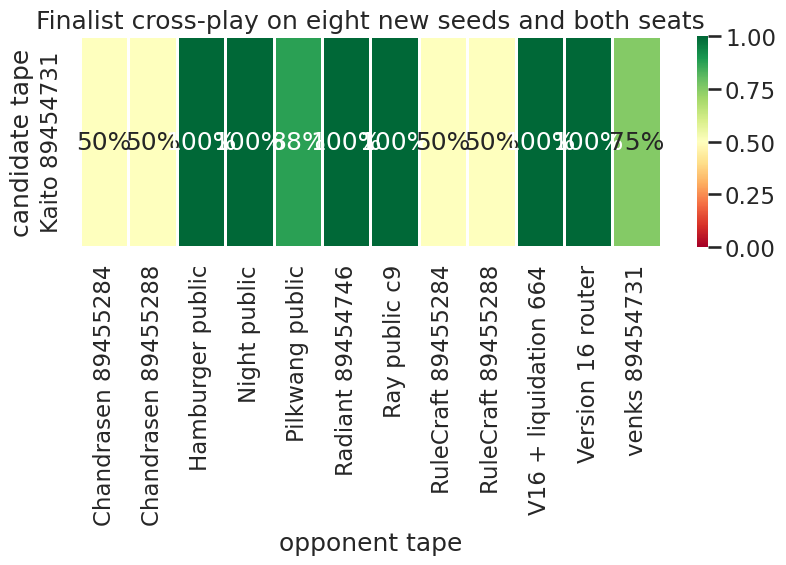

,challenger,opponent,games,wins,win_rate,mean_margin,challenger_label,opponent_label,candidate_episode,opponent_episode
2,newtoptrace:89454731:0,newtoptrace:89455284:0,16,8,0.500,3980.688,Kaito 89454731,Chandrasen 89455284,Kaito 89454731,Chandrasen 89455284
5,newtoptrace:89454731:0,newtoptrace:89455288:1,16,8,0.500,3980.688,Kaito 89454731,Chandrasen 89455288,Kaito 89454731,Chandrasen 89455288
0,newtoptrace:89454731:0,hamburger_fresh,16,16,1.000,8182.312,Kaito 89454731,Hamburger public,Kaito 89454731,Hamburger public
6,newtoptrace:89454731:0,night_fresh,16,16,1.000,8113.625,Kaito 89454731,Night public,Kaito 89454731,Night public
7,newtoptrace:89454731:0,pilkwang_fresh,16,14,0.875,5799.375,Kaito 89454731,Pilkwang public,Kaito 89454731,Pilkwang public
1,newtoptrace:89454731:0,newtoptrace:89454746:0,16,16,1.000,12957.562,Kaito 89454731,Radiant 89454746,Kaito 89454731,Radiant 89454746
10,newtoptrace:89454731:0,ray_c9_public,16,16,1.000,8049.562,Kaito 89454731,Ray public c9,Kaito 89454731,Ray public c9
3,newtoptrace:89454731:0,newtoptrace:89455284:1,16,8,0.500,3980.688,Kaito 89454731,RuleCraft 89455284,Kaito 89454731,RuleCraft 89455284
4,newtoptrace:89454731:0,newtoptrace:89455288:0,16,8,0.500,3980.688,Kaito 89454731,RuleCraft 89455288,Kaito 89454731,RuleCraft 89455288
8,newtoptrace:89454731:0,radiantliq:664,16,16,1.000,7789.562,Kaito 89454731,V16 + liquidation 664,Kaito 89454731,V16 + liquidation 664


In [3]:
CROSSPLAY_SUMMARY_ROWS = [{'challenger': 'newtoptrace:89454731:0', 'opponent': 'hamburger_fresh', 'games': 16, 'wins': 16, 'win_rate': 1.0, 'mean_margin': 8182.3125, 'challenger_label': 'Kaito 89454731', 'opponent_label': 'Hamburger public'}, {'challenger': 'newtoptrace:89454731:0', 'opponent': 'newtoptrace:89454746:0', 'games': 16, 'wins': 16, 'win_rate': 1.0, 'mean_margin': 12957.5625, 'challenger_label': 'Kaito 89454731', 'opponent_label': 'Radiant 89454746'}, {'challenger': 'newtoptrace:89454731:0', 'opponent': 'newtoptrace:89455284:0', 'games': 16, 'wins': 8, 'win_rate': 0.5, 'mean_margin': 3980.6875, 'challenger_label': 'Kaito 89454731', 'opponent_label': 'Chandrasen 89455284'}, {'challenger': 'newtoptrace:89454731:0', 'opponent': 'newtoptrace:89455284:1', 'games': 16, 'wins': 8, 'win_rate': 0.5, 'mean_margin': 3980.6875, 'challenger_label': 'Kaito 89454731', 'opponent_label': 'RuleCraft 89455284'}, {'challenger': 'newtoptrace:89454731:0', 'opponent': 'newtoptrace:89455288:0', 'games': 16, 'wins': 8, 'win_rate': 0.5, 'mean_margin': 3980.6875, 'challenger_label': 'Kaito 89454731', 'opponent_label': 'RuleCraft 89455288'}, {'challenger': 'newtoptrace:89454731:0', 'opponent': 'newtoptrace:89455288:1', 'games': 16, 'wins': 8, 'win_rate': 0.5, 'mean_margin': 3980.6875, 'challenger_label': 'Kaito 89454731', 'opponent_label': 'Chandrasen 89455288'}, {'challenger': 'newtoptrace:89454731:0', 'opponent': 'night_fresh', 'games': 16, 'wins': 16, 'win_rate': 1.0, 'mean_margin': 8113.625, 'challenger_label': 'Kaito 89454731', 'opponent_label': 'Night public'}, {'challenger': 'newtoptrace:89454731:0', 'opponent': 'pilkwang_fresh', 'games': 16, 'wins': 14, 'win_rate': 0.875, 'mean_margin': 5799.375, 'challenger_label': 'Kaito 89454731', 'opponent_label': 'Pilkwang public'}, {'challenger': 'newtoptrace:89454731:0', 'opponent': 'radiantliq:664', 'games': 16, 'wins': 16, 'win_rate': 1.0, 'mean_margin': 7789.5625, 'challenger_label': 'Kaito 89454731', 'opponent_label': 'V16 + liquidation 664'}, {'challenger': 'newtoptrace:89454731:0', 'opponent': 'radianttrace_router_v16', 'games': 16, 'wins': 16, 'win_rate': 1.0, 'mean_margin': 8308.75, 'challenger_label': 'Kaito 89454731', 'opponent_label': 'Version 16 router'}, {'challenger': 'newtoptrace:89454731:0', 'opponent': 'ray_c9_public', 'games': 16, 'wins': 16, 'win_rate': 1.0, 'mean_margin': 8049.5625, 'challenger_label': 'Kaito 89454731', 'opponent_label': 'Ray public c9'}, {'challenger': 'newtoptrace:89454731:0', 'opponent': 'venkstrace:89454731', 'games': 16, 'wins': 12, 'win_rate': 0.75, 'mean_margin': 192.8125, 'challenger_label': 'Kaito 89454731', 'opponent_label': 'venks 89454731'}]
crossplay = pd.DataFrame(CROSSPLAY_SUMMARY_ROWS)
crossplay["candidate_episode"] = crossplay.challenger_label
crossplay["opponent_episode"] = crossplay.opponent_label
duel = crossplay[crossplay.challenger != crossplay.opponent]
duel_view = duel.copy()
matrix = duel_view.pivot(index="candidate_episode", columns="opponent_episode", values="win_rate")
fig, ax = plt.subplots(figsize=(8.5, 6))
sns.heatmap(matrix, annot=True, fmt=".0%", vmin=0, vmax=1, center=.5, cmap="RdYlGn", linewidths=.8, ax=ax)
ax.set(title="Finalist cross-play on eight new seeds and both seats", xlabel="opponent tape", ylabel="candidate tape")
plt.tight_layout(); plt.show()
display(duel_view.sort_values(["candidate_episode", "opponent_episode"]).round(3))


## 2. Mathematical control: all melons is an opening, not a strategy

A watered melon tile can produce six premium units, but the sale curve is quadratic in glut. Dumping a whole monoculture into the same market makes each later tile sharply less valuable. The replay uses a small early melon tranche for explosive capital, then rotates into strawberries while livestock adds diversified milk, wool, and fertilizer value.


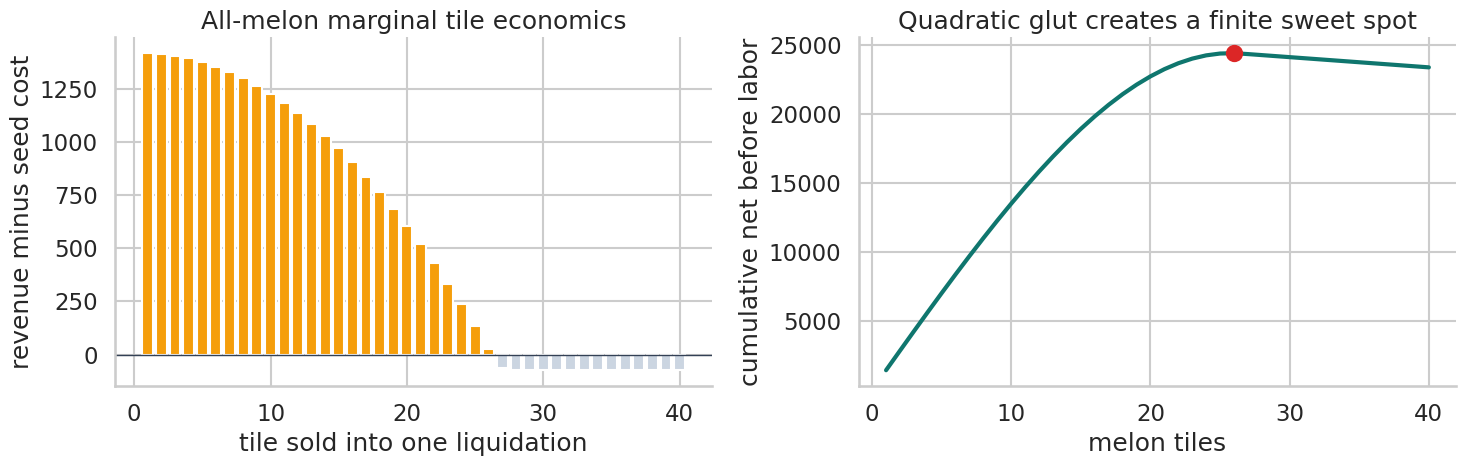

{'best_static_tile_count': 26, 'first_tile_net': 1420.0, 'fortieth_tile_net': -74.0}


In [4]:
def melon_price(glut):
    glut = np.maximum(0, np.asarray(glut))
    return np.maximum(1, np.rint(250 - (3.6 * 250 / 300**2) * glut**2))

tiles = np.arange(1, 41)
tile_net = np.array([melon_price(np.arange((i-1)*6, i*6)).sum() - 80 for i in tiles])
cumulative_net = np.cumsum(tile_net)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(tiles, tile_net, color=[COLORS[1] if x > 0 else "#cbd5e1" for x in tile_net])
axes[0].axhline(0, color="#334155", lw=1)
axes[0].set(title="All-melon marginal tile economics", xlabel="tile sold into one liquidation", ylabel="revenue minus seed cost")
axes[1].plot(tiles, cumulative_net, lw=3, color=COLORS[0])
axes[1].scatter([tiles[np.argmax(cumulative_net)]], [cumulative_net.max()], s=120, color=COLORS[4], zorder=3)
axes[1].set(title="Quadratic glut creates a finite sweet spot", xlabel="melon tiles", ylabel="cumulative net before labor")
sns.despine(); plt.tight_layout(); plt.show()
print({"best_static_tile_count": int(tiles[np.argmax(cumulative_net)]), "first_tile_net": float(tile_net[0]), "fortieth_tile_net": float(tile_net[-1])})


## 3. Teardown of public episode 89454731

These plots are descriptive measurements of the public replay—not evidence about hidden implementation. The public farm opens with three cows, one sheep, and six melon seeds, scales toward roughly 40 strawberry tiles, reaches 12 hands and three unlocked quadrants, and finishes with a balanced eight-cow, seven-sheep herd.


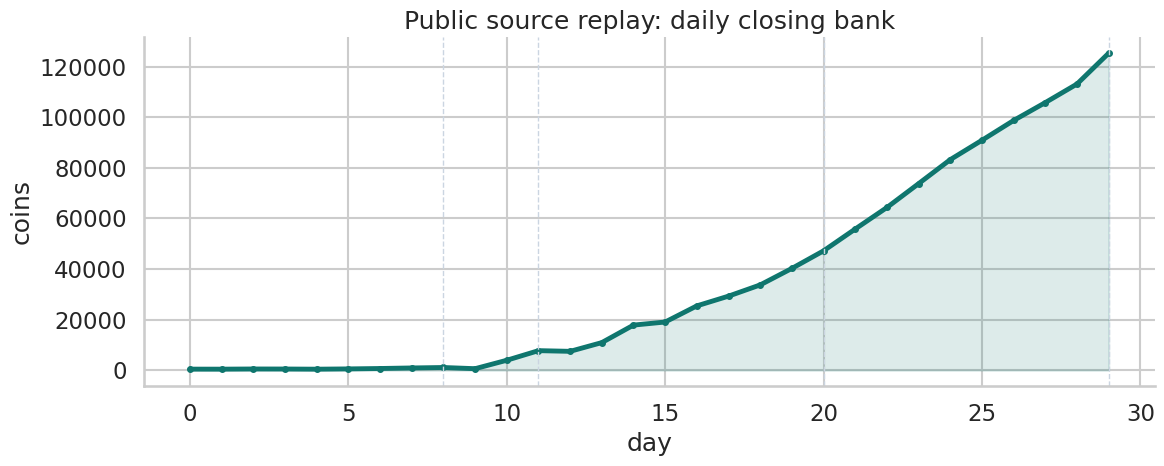

{'episode': 89454731, 'public_reward': 125364.0, 'public_opponent_reward': 128733.0}


In [5]:
DAILY_ROWS = [{'day': 0, 'money': 435.0, 'hands': 4, 'unlocked_quadrants': 1, 'crop_melon': 6, 'animal_sheep': 1, 'animal_buildings': 4, 'animal_cow': 3}, {'day': 1, 'money': 423.0, 'hands': 5, 'unlocked_quadrants': 1, 'crop_melon': 7, 'animal_sheep': 1, 'animal_buildings': 4, 'animal_cow': 3}, {'day': 2, 'money': 493.0, 'hands': 5, 'unlocked_quadrants': 1, 'crop_melon': 8, 'weed': 1, 'animal_sheep': 1, 'animal_buildings': 4, 'animal_cow': 3}, {'day': 3, 'money': 479.0, 'hands': 5, 'unlocked_quadrants': 1, 'crop_melon': 9, 'crop_strawberry': 2, 'weed': 1, 'animal_sheep': 1, 'animal_buildings': 4, 'animal_cow': 3}, {'day': 4, 'money': 412.0, 'hands': 6, 'unlocked_quadrants': 1, 'crop_melon': 9, 'crop_strawberry': 4, 'weed': 2, 'animal_sheep': 1, 'animal_buildings': 4, 'animal_cow': 3}, {'day': 5, 'money': 525.0, 'hands': 6, 'unlocked_quadrants': 1, 'crop_melon': 9, 'crop_strawberry': 6, 'weed': 2, 'animal_sheep': 1, 'animal_buildings': 4, 'animal_cow': 3}, {'day': 6, 'money': 684.0, 'hands': 6, 'unlocked_quadrants': 1, 'crop_melon': 9, 'crop_strawberry': 7, 'weed': 2, 'animal_sheep': 1, 'animal_buildings': 6, 'animal_cow': 4}, {'day': 7, 'money': 901.0, 'hands': 6, 'unlocked_quadrants': 1, 'crop_melon': 9, 'crop_strawberry': 7, 'weed': 2, 'animal_sheep': 1, 'animal_buildings': 6, 'animal_cow': 5}, {'day': 8, 'money': 1080.0, 'hands': 7, 'unlocked_quadrants': 2, 'crop_melon': 9, 'crop_strawberry': 10, 'weed': 2, 'animal_sheep': 4, 'animal_buildings': 10, 'animal_cow': 5}, {'day': 9, 'money': 612.0, 'hands': 10, 'unlocked_quadrants': 2, 'crop_melon': 9, 'crop_strawberry': 13, 'weed': 2, 'animal_sheep': 5, 'animal_buildings': 10, 'animal_cow': 5}, {'day': 10, 'money': 3944.0, 'hands': 10, 'unlocked_quadrants': 2, 'crop_melon': 5, 'crop_strawberry': 16, 'weed': 2, 'animal_sheep': 5, 'animal_buildings': 15, 'animal_cow': 5}, {'day': 11, 'money': 7741.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_strawberry': 21, 'crop_melon': 9, 'weed': 1, 'animal_sheep': 7, 'animal_buildings': 15, 'animal_cow': 7}, {'day': 12, 'money': 7472.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 31, 'crop_melon': 8, 'weed': 1, 'animal_sheep': 7, 'animal_buildings': 15, 'animal_cow': 8}, {'day': 13, 'money': 10928.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 35, 'crop_melon': 7, 'weed': 4, 'animal_sheep': 7, 'animal_buildings': 15, 'animal_cow': 8}, {'day': 14, 'money': 17846.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 38, 'crop_melon': 7, 'weed': 4, 'animal_sheep': 7, 'animal_buildings': 15, 'animal_cow': 8}, {'day': 15, 'money': 19064.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 40, 'crop_melon': 8, 'weed': 3, 'animal_sheep': 7, 'animal_buildings': 15, 'animal_cow': 8, 'crop_wheat': 2}, {'day': 16, 'money': 25449.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 40, 'crop_melon': 8, 'weed': 3, 'animal_sheep': 7, 'animal_buildings': 15, 'animal_cow': 8, 'crop_wheat': 3}, {'day': 17, 'money': 29300.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 40, 'crop_melon': 8, 'weed': 3, 'animal_sheep': 7, 'animal_buildings': 15, 'animal_cow': 8, 'crop_wheat': 3}, {'day': 18, 'money': 33737.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 40, 'crop_melon': 8, 'weed': 3, 'animal_sheep': 7, 'animal_buildings': 15, 'animal_cow': 8, 'crop_wheat': 3}, {'day': 19, 'money': 40260.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 40, 'crop_melon': 8, 'weed': 3, 'animal_sheep': 7, 'animal_buildings': 15, 'animal_cow': 8, 'crop_wheat': 1}, {'day': 20, 'money': 47215.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 38, 'crop_melon': 7, 'weed': 4, 'animal_sheep': 7, 'animal_buildings': 15, 'animal_cow': 8, 'crop_wheat': 1}, {'day': 21, 'money': 55842.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 36, 'weed': 4, 'animal_sheep': 7, 'animal_buildings': 15, 'animal_cow': 8, 'crop_melon': 1}, {'day': 22, 'money': 64351.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 34, 'weed': 3, 'animal_sheep': 7, 'animal_buildings': 15, 'animal_cow': 8, 'crop_melon': 1}, {'day': 23, 'money': 73779.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 33, 'weed': 2, 'animal_sheep': 7, 'animal_buildings': 15, 'animal_cow': 8, 'crop_melon': 1}, {'day': 24, 'money': 83280.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 33, 'weed': 2, 'animal_sheep': 7, 'animal_buildings': 15, 'animal_cow': 8, 'crop_melon': 1}, {'day': 25, 'money': 90935.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 30, 'weed': 2, 'animal_sheep': 7, 'animal_buildings': 15, 'animal_cow': 8, 'crop_melon': 1}, {'day': 26, 'money': 98761.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 26, 'weed': 4, 'animal_sheep': 7, 'animal_buildings': 15, 'animal_cow': 8}, {'day': 27, 'money': 105834.0, 'hands': 12, 'unlocked_quadrants': 3, 'crop_strawberry': 23, 'weed': 2, 'animal_sheep': 7, 'animal_buildings': 15, 'animal_cow': 8}, {'day': 28, 'money': 113175.0, 'hands': 11, 'unlocked_quadrants': 3, 'crop_strawberry': 18, 'weed': 2, 'animal_sheep': 7, 'animal_buildings': 15, 'animal_cow': 8}, {'day': 29, 'money': 125364.0, 'hands': 10, 'unlocked_quadrants': 3, 'weed': 14, 'crop_strawberry': 8, 'animal_sheep': 7, 'animal_buildings': 15, 'animal_cow': 8}]
daily = pd.DataFrame(DAILY_ROWS).fillna(0)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily.day, daily.money, lw=3.5, color=COLORS[0], marker="o", ms=4)
ax.fill_between(daily.day, daily.money, alpha=.14, color=COLORS[0])
for day in (8, 11, 20, 29): ax.axvline(day, color="#cbd5e1", ls="--", lw=1)
ax.set(title="Public source replay: daily closing bank", xlabel="day", ylabel="coins")
sns.despine(); plt.tight_layout(); plt.show()
print({"episode": 89454731, "public_reward": 125364.0, "public_opponent_reward": 128733.0})


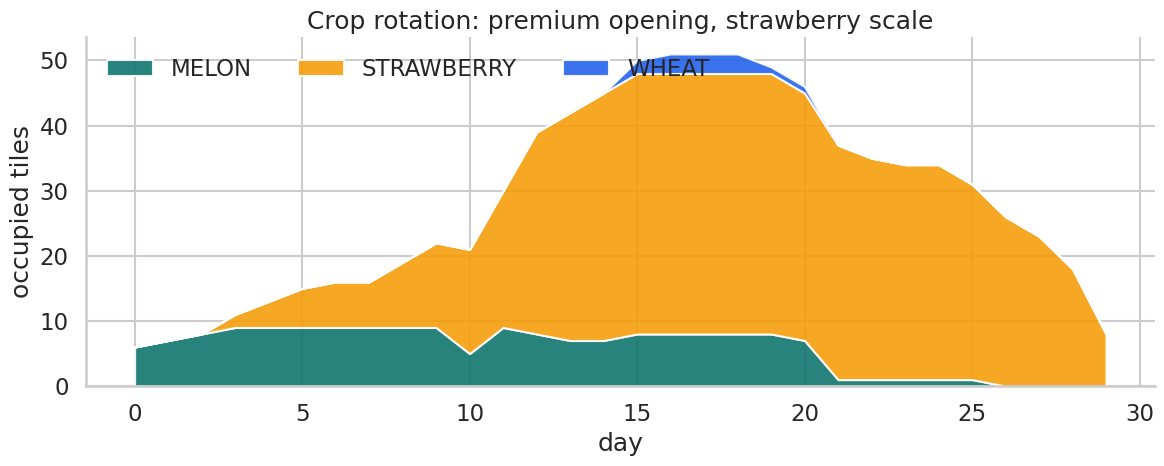

In [6]:
crop_cols = [c for c in daily if c.startswith("crop_")]
crop_labels = [c.replace("crop_", "").upper() for c in crop_cols]
fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(daily.day, *[daily[c] for c in crop_cols], labels=crop_labels,
             colors=COLORS[:len(crop_cols)], alpha=.9)
ax.set(title="Crop rotation: premium opening, strawberry scale", xlabel="day", ylabel="occupied tiles")
ax.legend(frameon=False, ncol=4, loc="upper left")
sns.despine(); plt.tight_layout(); plt.show()


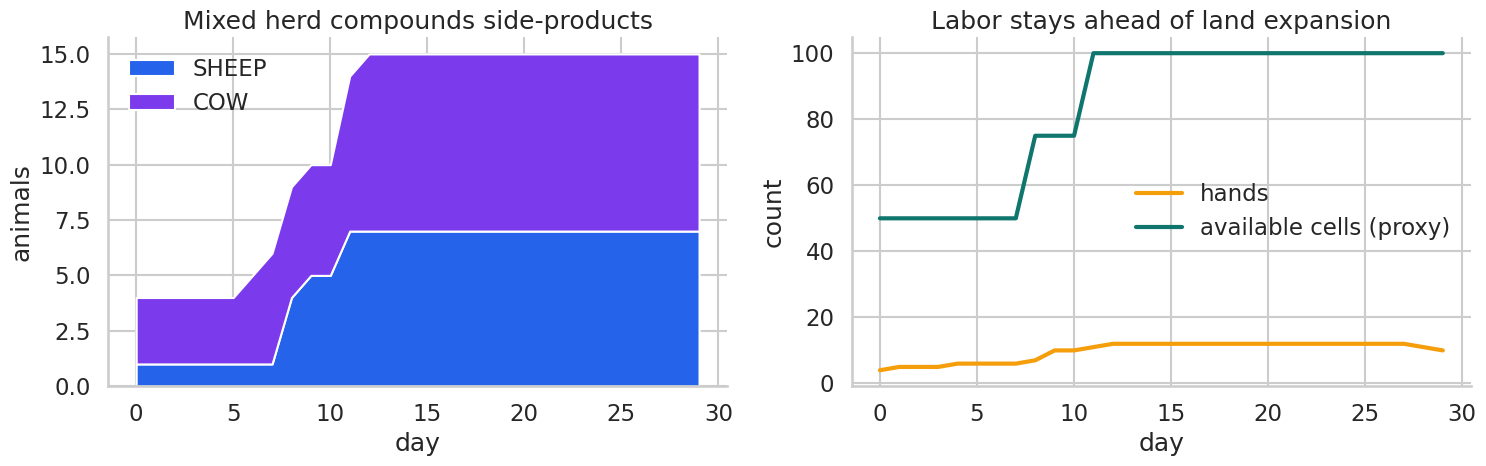

In [7]:
animal_cols = [c for c in daily if c.startswith("animal_") and c != "animal_buildings"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].stackplot(daily.day, *[daily[c] for c in animal_cols],
                  labels=[c.replace("animal_", "").upper() for c in animal_cols], colors=COLORS[2:2+len(animal_cols)])
axes[0].set(title="Mixed herd compounds side-products", xlabel="day", ylabel="animals")
axes[0].legend(frameon=False)
axes[1].plot(daily.day, daily.hands, lw=3, color=COLORS[1], label="hands")
axes[1].plot(daily.day, 25 * (1 + daily.unlocked_quadrants), lw=3, color=COLORS[0], label="available cells (proxy)")
axes[1].set(title="Labor stays ahead of land expansion", xlabel="day", ylabel="count")
axes[1].legend(frameon=False)
sns.despine(); plt.tight_layout(); plt.show()


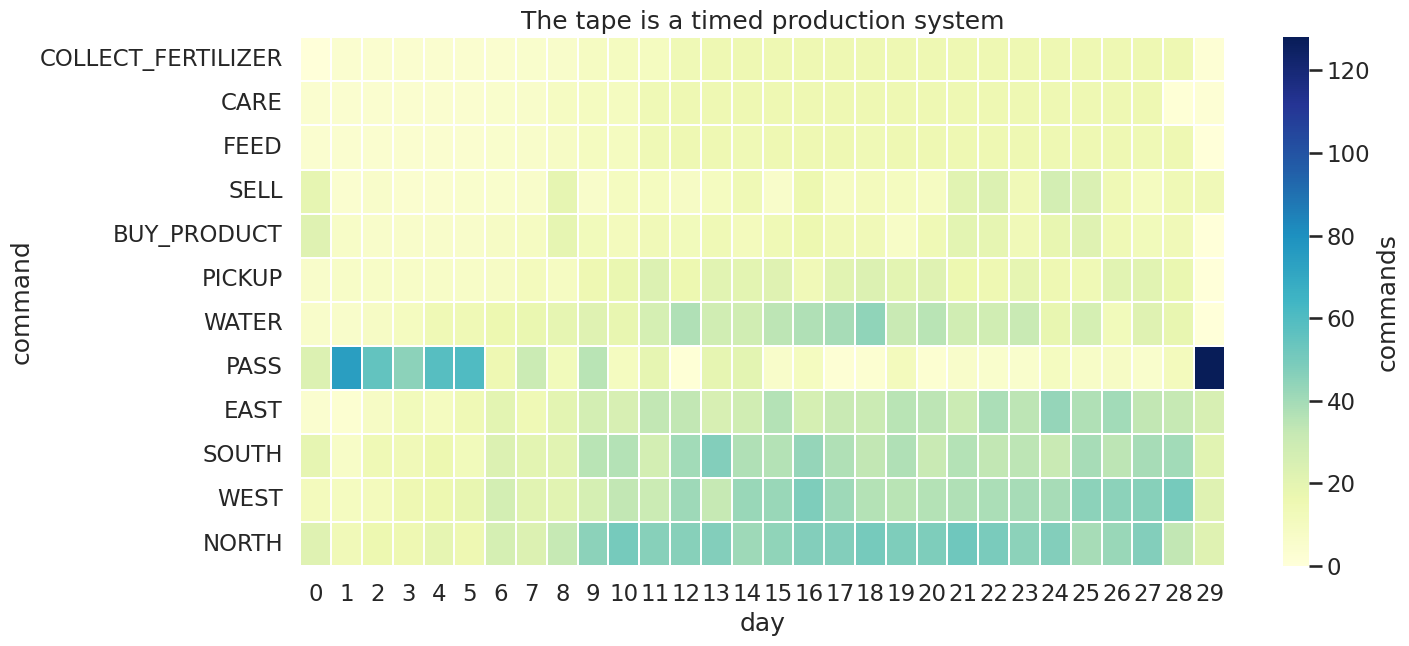

In [8]:
ACTION_SUMMARY_ROWS = [{'day': 0, 'verb': 'PASS', 'commands': 23}, {'day': 0, 'verb': 'HIRE', 'commands': 4}, {'day': 0, 'verb': 'BUY_ANIMAL', 'commands': 2}, {'day': 0, 'verb': 'BUY_SEED', 'commands': 1}, {'day': 0, 'verb': 'BUILD_PASTURE', 'commands': 4}, {'day': 0, 'verb': 'WEST', 'commands': 11}, {'day': 0, 'verb': 'NORTH', 'commands': 22}, {'day': 0, 'verb': 'BUY_PRODUCT', 'commands': 22}, {'day': 0, 'verb': 'PICKUP', 'commands': 6}, {'day': 0, 'verb': 'SELL', 'commands': 19}, {'day': 0, 'verb': 'PLACE', 'commands': 4}, {'day': 0, 'verb': 'SOUTH', 'commands': 19}, {'day': 0, 'verb': 'FEED', 'commands': 4}, {'day': 0, 'verb': 'CARE', 'commands': 4}, {'day': 0, 'verb': 'EAST', 'commands': 4}, {'day': 0, 'verb': 'PLANT', 'commands': 6}, {'day': 0, 'verb': 'WATER', 'commands': 6}, {'day': 1, 'verb': 'PICKUP', 'commands': 7}, {'day': 1, 'verb': 'SELL', 'commands': 4}, {'day': 1, 'verb': 'BUY_PRODUCT', 'commands': 7}, {'day': 1, 'verb': 'HIRE', 'commands': 5}, {'day': 1, 'verb': 'FEED', 'commands': 4}, {'day': 1, 'verb': 'WEST', 'commands': 10}, {'day': 1, 'verb': 'NORTH', 'commands': 13}, {'day': 1, 'verb': 'CARE', 'commands': 4}, {'day': 1, 'verb': 'COLLECT_FERTILIZER', 'commands': 4}, {'day': 1, 'verb': 'SOUTH', 'commands': 7}, {'day': 1, 'verb': 'EAST', 'commands': 3}, {'day': 1, 'verb': 'DROP', 'commands': 2}, {'day': 1, 'verb': 'PASS', 'commands': 74}, {'day': 1, 'verb': 'BUY_SEED', 'commands': 1}, {'day': 1, 'verb': 'PLANT', 'commands': 1}, {'day': 1, 'verb': 'WATER', 'commands': 6}, {'day': 2, 'verb': 'PICKUP', 'commands': 7}, {'day': 2, 'verb': 'SELL', 'commands': 6}, {'day': 2, 'verb': 'HIRE', 'commands': 5}, {'day': 2, 'verb': 'FEED', 'commands': 4}, {'day': 2, 'verb': 'WEST', 'commands': 11}, {'day': 2, 'verb': 'NORTH', 'commands': 16}, {'day': 2, 'verb': 'BUY_PRODUCT', 'commands': 6}, {'day': 2, 'verb': 'CARE', 'commands': 4}, {'day': 2, 'verb': 'COLLECT_FERTILIZER', 'commands': 4}, {'day': 2, 'verb': 'SOUTH', 'commands': 14}, {'day': 2, 'verb': 'EAST', 'commands': 8}, {'day': 2, 'verb': 'PASS', 'commands': 55}, {'day': 2, 'verb': 'DROP', 'commands': 3}, {'day': 2, 'verb': 'WATER', 'commands': 8}, {'day': 2, 'verb': 'BUY_SEED', 'commands': 2}, {'day': 2, 'verb': 'PLANT', 'commands': 1}, {'day': 3, 'verb': 'PICKUP', 'commands': 7}, {'day': 3, 'verb': 'SELL', 'commands': 4}, {'day': 3, 'verb': 'HIRE', 'commands': 5}, {'day': 3, 'verb': 'FEED', 'commands': 4}, {'day': 3, 'verb': 'WEST', 'commands': 15}, {'day': 3, 'verb': 'NORTH', 'commands': 15}, {'day': 3, 'verb': 'BUY_PRODUCT', 'commands': 6}, {'day': 3, 'verb': 'CARE', 'commands': 4}, {'day': 3, 'verb': 'COLLECT_FERTILIZER', 'commands': 4}, {'day': 3, 'verb': 'EAST', 'commands': 12}, {'day': 3, 'verb': 'PASS', 'commands': 45}, {'day': 3, 'verb': 'DROP', 'commands': 2}, {'day': 3, 'verb': 'WATER', 'commands': 10}, {'day': 3, 'verb': 'BUY_SEED', 'commands': 1}, {'day': 3, 'verb': 'PLANT', 'commands': 4}, {'day': 3, 'verb': 'SOUTH', 'commands': 13}, {'day': 4, 'verb': 'PICKUP', 'commands': 7}, {'day': 4, 'verb': 'SELL', 'commands': 4}, {'day': 4, 'verb': 'HIRE', 'commands': 6}, {'day': 4, 'verb': 'FEED', 'commands': 4}, {'day': 4, 'verb': 'WEST', 'commands': 16}, {'day': 4, 'verb': 'NORTH', 'commands': 19}, {'day': 4, 'verb': 'BUY_PRODUCT', 'commands': 6}, {'day': 4, 'verb': 'CARE', 'commands': 4}, {'day': 4, 'verb': 'COLLECT_FERTILIZER', 'commands': 4}, {'day': 4, 'verb': 'EAST', 'commands': 10}, {'day': 4, 'verb': 'SOUTH', 'commands': 16}, {'day': 4, 'verb': 'PASS', 'commands': 58}, {'day': 4, 'verb': 'DROP', 'commands': 1}, {'day': 4, 'verb': 'WATER', 'commands': 14}, {'day': 4, 'verb': 'BUY_SEED', 'commands': 1}, {'day': 4, 'verb': 'PLANT', 'commands': 2}, {'day': 4, 'verb': 'DIG', 'commands': 1}, {'day': 5, 'verb': 'PICKUP', 'commands': 7}, {'day': 5, 'verb': 'SELL', 'commands': 5}, {'day': 5, 'verb': 'HIRE', 'commands': 6}, {'day': 5, 'verb': 'FEED', 'commands': 4}, {'day': 5, 'verb': 'WEST', 'commands': 18}, {'day': 5, 'verb': 'NORTH', 'commands': 15}, {'day': 5, 'verb': 'BUY_PRODUCT', 'commands': 6}, {'day': 5, 'verb': 'BUY_SEED', 'commands': 2}, {'day': 5, 'verb': 'CARE', 'commands': 4}, {'day': 5, 'verb': 'COLLECT_FERTILIZER', 'commands': 4}, {'day': 5, 'verb': 'EAST', 'commands': 14}, {'day': 5, 'verb': 'SOUTH', 'commands': 12}, {'day': 5, 'verb': 'PASS', 'commands': 60}, {'day': 5, 'verb': 'DROP', 'commands': 2}, {'day': 5, 'verb': 'PLANT', 'commands': 2}, {'day': 5, 'verb': 'WATER', 'commands': 14}, {'day': 6, 'verb': 'PICKUP', 'commands': 8}, {'day': 6, 'verb': 'SELL', 'commands': 5}, {'day': 6, 'verb': 'HIRE', 'commands': 6}, {'day': 6, 'verb': 'FEED', 'commands': 5}, {'day': 6, 'verb': 'WEST', 'commands': 27}, {'day': 6, 'verb': 'NORTH', 'commands': 26}, {'day': 6, 'verb': 'BUY_PRODUCT', 'commands': 8}, {'day': 6, 'verb': 'BUY_SEED', 'commands': 2}, {'day': 6, 'verb': 'CARE', 'commands': 5}, {'day': 6, 'verb': 'COLLECT_FERTILIZER', 'commands': 4}, {'day': 6, 'verb': 'HARVEST', 'commands': 1}, {'day': 6, 'verb': 'EAST', 'commands': 20}, {'day': 6, 'verb': 'SOUTH', 'commands': 23}, {'day': 6, 'verb': 'DROP', 'commands': 2}, {'day': 6, 'verb': 'WATER', 'commands': 16}, {'day': 6, 'verb': 'PASS', 'commands': 15}, {'day': 6, 'verb': 'PLANT', 'commands': 1}, {'day': 6, 'verb': 'BUY_ANIMAL', 'commands': 1}, {'day': 6, 'verb': 'BUILD_PASTURE', 'commands': 2}, {'day': 6, 'verb': 'PLACE', 'commands': 1}, {'day': 7, 'verb': 'PICKUP', 'commands': 11}, {'day': 7, 'verb': 'SELL', 'commands': 6}, {'day': 7, 'verb': 'HIRE', 'commands': 6}, {'day': 7, 'verb': 'FEED', 'commands': 6}, {'day': 7, 'verb': 'WEST', 'commands': 21}, {'day': 7, 'verb': 'NORTH', 'commands': 23}, {'day': 7, 'verb': 'BUY_PRODUCT', 'commands': 9}, {'day': 7, 'verb': 'CARE', 'commands': 6}, {'day': 7, 'verb': 'COLLECT_FERTILIZER', 'commands': 5}, {'day': 7, 'verb': 'EAST', 'commands': 14}, {'day': 7, 'verb': 'SOUTH', 'commands': 20}, {'day': 7, 'verb': 'DROP', 'commands': 2}, {'day': 7, 'verb': 'WATER', 'commands': 17}, {'day': 7, 'verb': 'PASS', 'commands': 30}, {'day': 7, 'verb': 'PLACE', 'commands': 1}, {'day': 8, 'verb': 'PICKUP', 'commands': 9}, {'day': 8, 'verb': 'SELL', 'commands': 19}, {'day': 8, 'verb': 'HIRE', 'commands': 7}, {'day': 8, 'verb': 'FEED', 'commands': 8}, {'day': 8, 'verb': 'WEST', 'commands': 21}, {'day': 8, 'verb': 'NORTH', 'commands': 32}, {'day': 8, 'verb': 'BUY_PRODUCT', 'commands': 19}, {'day': 8, 'verb': 'HARVEST', 'commands': 3}, {'day': 8, 'verb': 'CARE', 'commands': 9}, {'day': 8, 'verb': 'DROP', 'commands': 4}, {'day': 8, 'verb': 'COLLECT_FERTILIZER', 'commands': 6}, {'day': 8, 'verb': 'BUY_ANIMAL', 'commands': 2}, {'day': 8, 'verb': 'SOUTH', 'commands': 21}, {'day': 8, 'verb': 'EAST', 'commands': 20}, {'day': 8, 'verb': 'BUY_LAND', 'commands': 1}, {'day': 8, 'verb': 'WATER', 'commands': 19}, {'day': 8, 'verb': 'BUY_SEED', 'commands': 1}, {'day': 8, 'verb': 'BUILD_PASTURE', 'commands': 4}, {'day': 8, 'verb': 'PASS', 'commands': 12}, {'day': 8, 'verb': 'PLANT', 'commands': 3}, {'day': 8, 'verb': 'PLACE', 'commands': 3}, {'day': 9, 'verb': 'PICKUP', 'commands': 15}, {'day': 9, 'verb': 'SELL', 'commands': 6}, {'day': 9, 'verb': 'BUY_PRODUCT', 'commands': 12}, {'day': 9, 'verb': 'HIRE', 'commands': 10}, {'day': 9, 'verb': 'FEED', 'commands': 10}, {'day': 9, 'verb': 'CARE', 'commands': 10}, {'day': 9, 'verb': 'NORTH', 'commands': 45}, {'day': 9, 'verb': 'COLLECT_FERTILIZER', 'commands': 9}, {'day': 9, 'verb': 'WEST', 'commands': 26}, {'day': 9, 'verb': 'EAST', 'commands': 27}, {'day': 9, 'verb': 'PLACE', 'commands': 1}, {'day': 9, 'verb': 'HARVEST', 'commands': 1}, {'day': 9, 'verb': 'SOUTH', 'commands': 35}, {'day': 9, 'verb': 'WATER', 'commands': 22}, {'day': 9, 'verb': 'DROP', 'commands': 3}, {'day': 9, 'verb': 'PASS', 'commands': 35}, {'day': 9, 'verb': 'PLANT', 'commands': 3}, {'day': 10, 'verb': 'PICKUP', 'commands': 17}, {'day': 10, 'verb': 'SELL', 'commands': 10}, {'day': 10, 'verb': 'HIRE', 'commands': 10}, {'day': 10, 'verb': 'BUY_SEED', 'commands': 5}, {'day': 10, 'verb': 'FEED', 'commands': 10}, {'day': 10, 'verb': 'CARE', 'commands': 10}, {'day': 10, 'verb': 'NORTH', 'commands': 50}, {'day': 10, 'verb': 'BUY_PRODUCT', 'commands': 11}, {'day': 10, 'verb': 'COLLECT_FERTILIZER', 'commands': 10}, {'day': 10, 'verb': 'WEST', 'commands': 33}, {'day': 10, 'verb': 'EAST', 'commands': 25}, {'day': 10, 'verb': 'HARVEST', 'commands': 9}, {'day': 10, 'verb': 'PLANT', 'commands': 5}, {'day': 10, 'verb': 'SOUTH', 'commands': 36}, {'day': 10, 'verb': 'WATER', 'commands': 18}, {'day': 10, 'verb': 'DROP', 'commands': 4}, {'day': 10, 'verb': 'PASS', 'commands': 10}, {'day': 10, 'verb': 'BUY_ANIMAL', 'commands': 2}, {'day': 10, 'verb': 'BUILD_PASTURE', 'commands': 5}, {'day': 11, 'verb': 'PICKUP', 'commands': 23}, {'day': 11, 'verb': 'SELL', 'commands': 10}, {'day': 11, 'verb': 'HIRE', 'commands': 11}, {'day': 11, 'verb': 'FEED', 'commands': 14}, {'day': 11, 'verb': 'CARE', 'commands': 14}, {'day': 11, 'verb': 'NORTH', 'commands': 46}, {'day': 11, 'verb': 'BUY_PRODUCT', 'commands': 13}, {'day': 11, 'verb': 'COLLECT_FERTILIZER', 'commands': 10}, {'day': 11, 'verb': 'WEST', 'commands': 30}, {'day': 11, 'verb': 'EAST', 'commands': 33}, {'day': 11, 'verb': 'PLACE', 'commands': 4}, {'day': 11, 'verb': 'WATER', 'commands': 26}, {'day': 11, 'verb': 'SOUTH', 'commands': 27}, {'day': 11, 'verb': 'HARVEST', 'commands': 1}, {'day': 11, 'verb': 'PLANT', 'commands': 11}, {'day': 11, 'verb': 'DROP', 'commands': 3}, {'day': 11, 'verb': 'PASS', 'commands': 19}, {'day': 11, 'verb': 'BUY_SEED', 'commands': 6}, {'day': 11, 'verb': 'BUY_LAND', 'commands': 1}, {'day': 11, 'verb': 'DIG', 'commands': 1}, {'day': 12, 'verb': 'PICKUP', 'commands': 16}, {'day': 12, 'verb': 'SELL', 'commands': 8}, {'day': 12, 'verb': 'BUY_PRODUCT', 'commands': 12}, {'day': 12, 'verb': 'HIRE', 'commands': 12}, {'day': 12, 'verb': 'BUY_SEED', 'commands': 10}, {'day': 12, 'verb': 'FEED', 'commands': 15}, {'day': 12, 'verb': 'CARE', 'commands': 15}, {'day': 12, 'verb': 'NORTH', 'commands': 46}, {'day': 12, 'verb': 'COLLECT_FERTILIZER', 'commands': 14}, {'day': 12, 'verb': 'WEST', 'commands': 41}, {'day': 12, 'verb': 'HARVEST', 'commands': 5}, {'day': 12, 'verb': 'EAST', 'commands': 33}, {'day': 12, 'verb': 'WATER', 'commands': 37}, {'day': 12, 'verb': 'SOUTH', 'commands': 40}, {'day': 12, 'verb': 'DIG', 'commands': 1}, {'day': 12, 'verb': 'PLANT', 'commands': 12}, {'day': 12, 'verb': 'PLACE', 'commands': 1}, {'day': 12, 'verb': 'FERTILIZE', 'commands': 2}, {'day': 12, 'verb': 'DROP', 'commands': 3}, {'day': 12, 'verb': 'PASS', 'commands': 1}, {'day': 13, 'verb': 'PICKUP', 'commands': 21}, {'day': 13, 'verb': 'SELL', 'commands': 10}, {'day': 13, 'verb': 'BUY_PRODUCT', 'commands': 14}, {'day': 13, 'verb': 'HIRE', 'commands': 12}, {'day': 13, 'verb': 'BUY_SEED', 'commands': 7}, {'day': 13, 'verb': 'FEED', 'commands': 15}, {'day': 13, 'verb': 'CARE', 'commands': 15}, {'day': 13, 'verb': 'NORTH', 'commands': 47}, {'day': 13, 'verb': 'COLLECT_FERTILIZER', 'commands': 15}, {'day': 13, 'verb': 'WEST', 'commands': 32}, {'day': 13, 'verb': 'EAST', 'commands': 25}, {'day': 13, 'verb': 'WATER', 'commands': 28}, {'day': 13, 'verb': 'SOUTH', 'commands': 47}, {'day': 13, 'verb': 'FERTILIZE', 'commands': 2}, {'day': 13, 'verb': 'HARVEST', 'commands': 4}, {'day': 13, 'verb': 'PLANT', 'commands': 7}, {'day': 13, 'verb': 'DROP', 'commands': 3}, {'day': 13, 'verb': 'PASS', 'commands': 19}, {'day': 13, 'verb': 'DIG', 'commands': 2}, {'day': 14, 'verb': 'PICKUP', 'commands': 20}, {'day': 14, 'verb': 'SELL', 'commands': 14}, {'day': 14, 'verb': 'BUY_PRODUCT', 'commands': 11}, {'day': 14, 'verb': 'HIRE', 'commands': 12}, {'day': 14, 'verb': 'BUY_SEED', 'commands': 3}, {'day': 14, 'verb': 'FEED', 'commands': 14}, {'day': 14, 'verb': 'HARVEST', 'commands': 9}, {'day': 14, 'verb': 'NORTH', 'commands': 41}, {'day': 14, 'verb': 'WEST', 'commands': 42}, {'day': 14, 'verb': 'CARE', 'commands': 15}, {'day': 14, 'verb': 'COLLECT_FERTILIZER', 'commands': 15}, {'day': 14, 'verb': 'EAST', 'commands': 28}, {'day': 14, 'verb': 'WATER', 'commands': 28}, {'day': 14, 'verb': 'SOUTH', 'commands': 37}, {'day': 14, 'verb': 'FERTILIZE', 'commands': 2}, {'day': 14, 'verb': 'DROP', 'commands': 7}, {'day': 14, 'verb': 'PASS', 'commands': 20}, {'day': 14, 'verb': 'PLANT', 'commands': 4}, {'day': 15, 'verb': 'PICKUP', 'commands': 22}, {'day': 15, 'verb': 'SELL', 'commands': 6}, {'day': 15, 'verb': 'HIRE', 'commands': 12}, {'day': 15, 'verb': 'FEED', 'commands': 15}, {'day': 15, 'verb': 'CARE', 'commands': 15}, {'day': 15, 'verb': 'NORTH', 'commands': 44}, {'day': 15, 'verb': 'BUY_PRODUCT', 'commands': 14}, {'day': 15, 'verb': 'COLLECT_FERTILIZER', 'commands': 15}, {'day': 15, 'verb': 'WEST', 'commands': 42}, {'day': 15, 'verb': 'EAST', 'commands': 36}, {'day': 15, 'verb': 'SOUTH', 'commands': 36}, {'day': 15, 'verb': 'HARVEST', 'commands': 7}, {'day': 15, 'verb': 'WATER', 'commands': 34}, {'day': 15, 'verb': 'PLANT', 'commands': 6}, {'day': 15, 'verb': 'DIG', 'commands': 2}, {'day': 15, 'verb': 'BUY_SEED', 'commands': 2}, {'day': 15, 'verb': 'FERTILIZE', 'commands': 1}, {'day': 15, 'verb': 'PASS', 'commands': 6}, {'day': 15, 'verb': 'DROP', 'commands': 1}, {'day': 16, 'verb': 'PICKUP', 'commands': 13}, {'day': 16, 'verb': 'SELL', 'commands': 16}, {'day': 16, 'verb': 'HIRE', 'commands': 12}, {'day': 16, 'verb': 'FEED', 'commands': 15}, {'day': 16, 'verb': 'CARE', 'commands': 15}, {'day': 16, 'verb': 'NORTH', 'commands': 47}, {'day': 16, 'verb': 'BUY_PRODUCT', 'commands': 16}, {'day': 16, 'verb': 'COLLECT_FERTILIZER', 'commands': 15}, {'day': 16, 'verb': 'WEST', 'commands': 48}, {'day': 16, 'verb': 'SOUTH', 'commands': 43}, {'day': 16, 'verb': 'HARVEST', 'commands': 7}, {'day': 16, 'verb': 'EAST', 'commands': 26}, {'day': 16, 'verb': 'WATER', 'commands': 37}, {'day': 16, 'verb': 'PLANT', 'commands': 1}, {'day': 16, 'verb': 'FERTILIZE', 'commands': 4}, {'day': 16, 'verb': 'DROP', 'commands': 1}, {'day': 16, 'verb': 'PASS', 'commands': 10}, {'day': 17, 'verb': 'PICKUP', 'commands': 21}, {'day': 17, 'verb': 'SELL', 'commands': 9}, {'day': 17, 'verb': 'BUY_PRODUCT', 'commands': 13}, {'day': 17, 'verb': 'HIRE', 'commands': 12}, {'day': 17, 'verb': 'FEED', 'commands': 15}, {'day': 17, 'verb': 'HARVEST', 'commands': 10}, {'day': 17, 'verb': 'NORTH', 'commands': 47}, {'day': 17, 'verb': 'CARE', 'commands': 15}, {'day': 17, 'verb': 'COLLECT_FERTILIZER', 'commands': 15}, {'day': 17, 'verb': 'WEST', 'commands': 41}, {'day': 17, 'verb': 'SOUTH', 'commands': 37}, {'day': 17, 'verb': 'EAST', 'commands': 31}, {'day': 17, 'verb': 'WATER', 'commands': 39}, {'day': 17, 'verb': 'FERTILIZE', 'commands': 6}, {'day': 17, 'verb': 'DROP', 'commands': 3}, {'day': 17, 'verb': 'PASS', 'commands': 2}, {'day': 18, 'verb': 'PICKUP', 'commands': 23}, {'day': 18, 'verb': 'SELL', 'commands': 11}, {'day': 18, 'verb': 'HIRE', 'commands': 12}, {'day': 18, 'verb': 'FEED', 'commands': 14}, {'day': 18, 'verb': 'CARE', 'commands': 15}, {'day': 18, 'verb': 'NORTH', 'commands': 50}, {'day': 18, 'verb': 'BUY_PRODUCT', 'commands': 13}, {'day': 18, 'verb': 'COLLECT_FERTILIZER', 'commands': 15}, {'day': 18, 'verb': 'WEST', 'commands': 36}, {'day': 18, 'verb': 'EAST', 'commands': 30}, {'day': 18, 'verb': 'SOUTH', 'commands': 33}, {'day': 18, 'verb': 'HARVEST', 'commands': 12}, {'day': 18, 'verb': 'WATER', 'commands': 44}, {'day': 18, 'verb': 'DROP', 'commands': 2}, {'day': 18, 'verb': 'FERTILIZE', 'commands': 5}, {'day': 18, 'verb': 'PASS', 'commands': 3}, {'day': 19, 'verb': 'PICKUP', 'commands': 20}, {'day': 19, 'verb': 'SELL', 'commands': 10}, {'day': 19, 'verb': 'HIRE', 'commands': 12}, {'day': 19, 'verb': 'FEED', 'commands': 15}, {'day': 19, 'verb': 'CARE', 'commands': 15}, {'day': 19, 'verb': 'NORTH', 'commands': 48}, {'day': 19, 'verb': 'BUY_PRODUCT', 'commands': 7}, {'day': 19, 'verb': 'COLLECT_FERTILIZER', 'commands': 15}, {'day': 19, 'verb': 'WEST', 'commands': 35}, {'day': 19, 'verb': 'SOUTH', 'commands': 37}, {'day': 19, 'verb': 'EAST', 'commands': 35}, {'day': 19, 'verb': 'WATER', 'commands': 31}, {'day': 19, 'verb': 'HARVEST', 'commands': 13}, {'day': 19, 'verb': 'FERTILIZE', 'commands': 4}, {'day': 19, 'verb': 'DROP', 'commands': 3}, {'day': 19, 'verb': 'PASS', 'commands': 11}, {'day': 20, 'verb': 'PICKUP', 'commands': 22}, {'day': 20, 'verb': 'SELL', 'commands': 9}, {'day': 20, 'verb': 'HIRE', 'commands': 12}, {'day': 20, 'verb': 'FEED', 'commands': 15}, {'day': 20, 'verb': 'HARVEST', 'commands': 21}, {'day': 20, 'verb': 'NORTH', 'commands': 48}, {'day': 20, 'verb': 'BUY_PRODUCT', 'commands': 14}, {'day': 20, 'verb': 'CARE', 'commands': 15}, {'day': 20, 'verb': 'COLLECT_FERTILIZER', 'commands': 15}, {'day': 20, 'verb': 'WEST', 'commands': 36}, {'day': 20, 'verb': 'EAST', 'commands': 34}, {'day': 20, 'verb': 'SOUTH', 'commands': 31}, {'day': 20, 'verb': 'WATER', 'commands': 35}, {'day': 20, 'verb': 'FERTILIZE', 'commands': 4}, {'day': 20, 'verb': 'DIG', 'commands': 1}, {'day': 20, 'verb': 'DROP', 'commands': 2}, {'day': 20, 'verb': 'PASS', 'commands': 3}, {'day': 21, 'verb': 'PICKUP', 'commands': 16}, {'day': 21, 'verb': 'SELL', 'commands': 21}, {'day': 21, 'verb': 'BUY_PRODUCT', 'commands': 20}, {'day': 21, 'verb': 'HIRE', 'commands': 12}, {'day': 21, 'verb': 'FEED', 'commands': 15}, {'day': 21, 'verb': 'CARE', 'commands': 15}, {'day': 21, 'verb': 'NORTH', 'commands': 52}, {'day': 21, 'verb': 'COLLECT_FERTILIZER', 'commands': 15}, {'day': 21, 'verb': 'WEST', 'commands': 37}, {'day': 21, 'verb': 'EAST', 'commands': 30}, {'day': 21, 'verb': 'SOUTH', 'commands': 36}, {'day': 21, 'verb': 'HARVEST', 'commands': 17}, {'day': 21, 'verb': 'WATER', 'commands': 28}, {'day': 21, 'verb': 'FERTILIZE', 'commands': 10}, {'day': 21, 'verb': 'DIG', 'commands': 3}, {'day': 21, 'verb': 'DROP', 'commands': 2}, {'day': 21, 'verb': 'PASS', 'commands': 6}, {'day': 22, 'verb': 'PICKUP', 'commands': 15}, {'day': 22, 'verb': 'SELL', 'commands': 23}, {'day': 22, 'verb': 'BUY_PRODUCT', 'commands': 19}, {'day': 22, 'verb': 'HIRE', 'commands': 12}, {'day': 22, 'verb': 'FEED', 'commands': 15}, {'day': 22, 'verb': 'CARE', 'commands': 15}, {'day': 22, 'verb': 'NORTH', 'commands': 49}, {'day': 22, 'verb': 'COLLECT_FERTILIZER', 'commands': 15}, {'day': 22, 'verb': 'WEST', 'commands': 38}, {'day': 22, 'verb': 'SOUTH', 'commands': 33}, {'day': 22, 'verb': 'HARVEST', 'commands': 21}, {'day': 22, 'verb': 'EAST', 'commands': 38}, {'day': 22, 'verb': 'WATER', 'commands': 28}, {'day': 22, 'verb': 'DIG', 'commands': 3}, {'day': 22, 'verb': 'FERTILIZE', 'commands': 6}, {'day': 22, 'verb': 'DROP', 'commands': 1}, {'day': 22, 'verb': 'PASS', 'commands': 5}, {'day': 23, 'verb': 'PICKUP', 'commands': 19}, {'day': 23, 'verb': 'SELL', 'commands': 13}, {'day': 23, 'verb': 'BUY_PRODUCT', 'commands': 13}, {'day': 23, 'verb': 'HIRE', 'commands': 12}, {'day': 23, 'verb': 'FEED', 'commands': 15}, {'day': 23, 'verb': 'HARVEST', 'commands': 18}, {'day': 23, 'verb': 'NORTH', 'commands': 45}, {'day': 23, 'verb': 'CARE', 'commands': 15}, {'day': 23, 'verb': 'COLLECT_FERTILIZER', 'commands': 15}, {'day': 23, 'verb': 'WEST', 'commands': 39}, {'day': 23, 'verb': 'SOUTH', 'commands': 34}, {'day': 23, 'verb': 'EAST', 'commands': 34}, {'day': 23, 'verb': 'WATER', 'commands': 31}, {'day': 23, 'verb': 'DIG', 'commands': 2}, {'day': 23, 'verb': 'FERTILIZE', 'commands': 8}, {'day': 23, 'verb': 'DROP', 'commands': 2}, {'day': 23, 'verb': 'PASS', 'commands': 5}, {'day': 24, 'verb': 'PICKUP', 'commands': 15}, {'day': 24, 'verb': 'SELL', 'commands': 27}, {'day': 24, 'verb': 'HIRE', 'commands': 12}, {'day': 24, 'verb': 'FEED', 'commands': 15}, {'day': 24, 'verb': 'CARE', 'commands': 15}, {'day': 24, 'verb': 'NORTH', 'commands': 47}, {'day': 24, 'verb': 'BUY_PRODUCT', 'commands': 18}, {'day': 24, 'verb': 'COLLECT_FERTILIZER', 'commands': 15}, {'day': 24, 'verb': 'WEST', 'commands': 39}, {'day': 24, 'verb': 'SOUTH', 'commands': 31}, {'day': 24, 'verb': 'HARVEST', 'commands': 24}, {'day': 24, 'verb': 'EAST', 'commands': 43}, {'day': 24, 'verb': 'WATER', 'commands': 18}, {'day': 24, 'verb': 'DIG', 'commands': 1}, {'day': 24, 'verb': 'FERTILIZE', 'commands': 3}, {'day': 24, 'verb': 'DROP', 'commands': 6}, {'day': 24, 'verb': 'PASS', 'commands': 10}, {'day': 25, 'verb': 'PICKUP', 'commands': 14}, {'day': 25, 'verb': 'SELL', 'commands': 24}, {'day': 25, 'verb': 'BUY_PRODUCT', 'commands': 22}, {'day': 25, 'verb': 'HIRE', 'commands': 12}, {'day': 25, 'verb': 'FEED', 'commands': 15}, {'day': 25, 'verb': 'CARE', 'commands': 15}, {'day': 25, 'verb': 'NORTH', 'commands': 39}, {'day': 25, 'verb': 'COLLECT_FERTILIZER', 'commands': 15}, {'day': 25, 'verb': 'WEST', 'commands': 45}, {'day': 25, 'verb': 'EAST', 'commands': 37}, {'day': 25, 'verb': 'WATER', 'commands': 26}, {'day': 25, 'verb': 'SOUTH', 'commands': 39}, {'day': 25, 'verb': 'FERTILIZE', 'commands': 7}, {'day': 25, 'verb': 'HARVEST', 'commands': 17}, {'day': 25, 'verb': 'DIG', 'commands': 3}, {'day': 25, 'verb': 'DROP', 'commands': 3}, {'day': 25, 'verb': 'PASS', 'commands': 7}, {'day': 26, 'verb': 'PICKUP', 'commands': 21}, {'day': 26, 'verb': 'SELL', 'commands': 14}, {'day': 26, 'verb': 'BUY_PRODUCT', 'commands': 14}, {'day': 26, 'verb': 'HIRE', 'commands': 12}, {'day': 26, 'verb': 'FEED', 'commands': 15}, {'day': 26, 'verb': 'HARVEST', 'commands': 22}, {'day': 26, 'verb': 'NORTH', 'commands': 42}, {'day': 26, 'verb': 'CARE', 'commands': 15}, {'day': 26, 'verb': 'COLLECT_FERTILIZER', 'commands': 15}, {'day': 26, 'verb': 'WEST', 'commands': 45}, {'day': 26, 'verb': 'EAST', 'commands': 40}, {'day': 26, 'verb': 'SOUTH', 'commands': 34}, {'day': 26, 'verb': 'DROP', 'commands': 6}, {'day': 26, 'verb': 'WATER', 'commands': 12}, {'day': 26, 'verb': 'FERTILIZE', 'commands': 4}, {'day': 26, 'verb': 'DIG', 'commands': 3}, {'day': 26, 'verb': 'PASS', 'commands': 8}, {'day': 27, 'verb': 'PICKUP', 'commands': 21}, {'day': 27, 'verb': 'SELL', 'commands': 10}, {'day': 27, 'verb': 'HIRE', 'commands': 12}, {'day': 27, 'verb': 'FEED', 'commands': 14}, {'day': 27, 'verb': 'CARE', 'commands': 15}, {'day': 27, 'verb': 'NORTH', 'commands': 47}, {'day': 27, 'verb': 'BUY_PRODUCT', 'commands': 12}, {'day': 27, 'verb': 'COLLECT_FERTILIZER', 'commands': 15}, {'day': 27, 'verb': 'WEST', 'commands': 46}, {'day': 27, 'verb': 'EAST', 'commands': 33}, {'day': 27, 'verb': 'SOUTH', 'commands': 39}, {'day': 27, 'verb': 'HARVEST', 'commands': 15}, {'day': 27, 'verb': 'WATER', 'commands': 22}, {'day': 27, 'verb': 'DIG', 'commands': 5}, {'day': 27, 'verb': 'FERTILIZE', 'commands': 3}, {'day': 27, 'verb': 'DROP', 'commands': 2}, {'day': 27, 'verb': 'PASS', 'commands': 5}, {'day': 28, 'verb': 'PICKUP', 'commands': 17}, {'day': 28, 'verb': 'SELL', 'commands': 14}, {'day': 28, 'verb': 'HIRE', 'commands': 11}, {'day': 28, 'verb': 'FEED', 'commands': 15}, {'day': 28, 'verb': 'COLLECT_FERTILIZER', 'commands': 15}, {'day': 28, 'verb': 'NORTH', 'commands': 33}, {'day': 28, 'verb': 'BUY_PRODUCT', 'commands': 13}, {'day': 28, 'verb': 'WEST', 'commands': 50}, {'day': 28, 'verb': 'EAST', 'commands': 32}, {'day': 28, 'verb': 'HARVEST', 'commands': 17}, {'day': 28, 'verb': 'SOUTH', 'commands': 40}, {'day': 28, 'verb': 'DROP', 'commands': 4}, {'day': 28, 'verb': 'DIG', 'commands': 5}, {'day': 28, 'verb': 'WATER', 'commands': 18}, {'day': 28, 'verb': 'FERTILIZE', 'commands': 4}, {'day': 28, 'verb': 'CARE', 'commands': 1}, {'day': 28, 'verb': 'PASS', 'commands': 11}, {'day': 29, 'verb': 'EAST', 'commands': 25}, {'day': 29, 'verb': 'SELL', 'commands': 13}, {'day': 29, 'verb': 'HIRE', 'commands': 10}, {'day': 29, 'verb': 'HARVEST', 'commands': 16}, {'day': 29, 'verb': 'NORTH', 'commands': 22}, {'day': 29, 'verb': 'SOUTH', 'commands': 21}, {'day': 29, 'verb': 'WEST', 'commands': 22}, {'day': 29, 'verb': 'DROP', 'commands': 8}, {'day': 29, 'verb': 'CARE', 'commands': 2}, {'day': 29, 'verb': 'PASS', 'commands': 128}, {'day': 29, 'verb': 'COLLECT_FERTILIZER', 'commands': 2}]
actions = pd.DataFrame(ACTION_SUMMARY_ROWS)
common = actions.groupby("verb").commands.sum().nlargest(12).index
action_heat = actions[actions.verb.isin(common)].pivot_table(index="verb", columns="day", values="commands", aggfunc="sum", fill_value=0)
action_heat = action_heat.loc[action_heat.sum(axis=1).sort_values().index]
fig, ax = plt.subplots(figsize=(15, 6.8))
sns.heatmap(action_heat, cmap="YlGnBu", linewidths=.15, cbar_kws={"label":"commands"}, ax=ax)
ax.set(title="The tape is a timed production system", xlabel="day", ylabel="command")
plt.tight_layout(); plt.show()


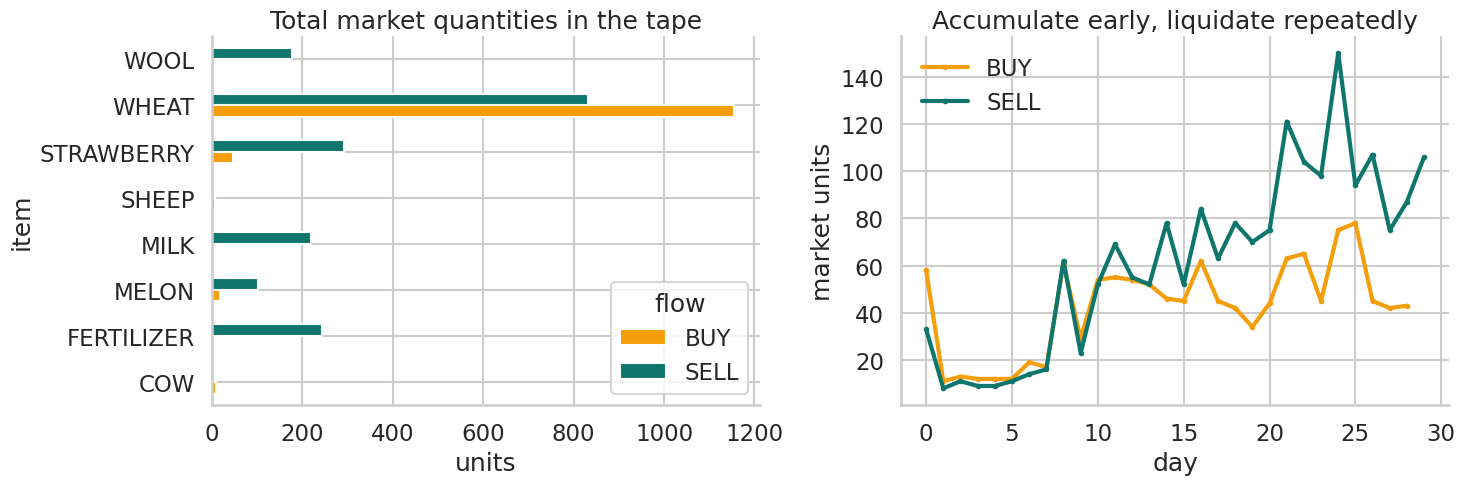

flow,BUY,SELL
item,,
COW,8.0,0.0
FERTILIZER,0.0,243.0
MELON,18.0,102.0
MILK,0.0,220.0
SHEEP,7.0,0.0
STRAWBERRY,46.0,292.0
WHEAT,1154.0,832.0
WOOL,0.0,177.0


In [9]:
MARKET_SUMMARY_ROWS = [{'day': 0, 'flow': 'BUY', 'item': 'COW', 'quantity': 3.0}, {'day': 0, 'flow': 'BUY', 'item': 'MELON', 'quantity': 6.0}, {'day': 0, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 48.0}, {'day': 0, 'flow': 'BUY', 'item': 'SHEEP', 'quantity': 1.0}, {'day': 0, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 33.0}, {'day': 1, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 5.0}, {'day': 1, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 1, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 3.0}, {'day': 1, 'flow': 'BUY', 'item': 'MELON', 'quantity': 1.0}, {'day': 2, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 6.0}, {'day': 2, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 5.0}, {'day': 2, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 2, 'flow': 'BUY', 'item': 'MELON', 'quantity': 1.0}, {'day': 2, 'flow': 'BUY', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 3, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 6.0}, {'day': 3, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 3, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 3.0}, {'day': 3, 'flow': 'BUY', 'item': 'MELON', 'quantity': 2.0}, {'day': 4, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 3.0}, {'day': 4, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 6.0}, {'day': 4, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 4, 'flow': 'BUY', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 5, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 5.0}, {'day': 5, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 6.0}, {'day': 5, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 10.0}, {'day': 5, 'flow': 'BUY', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 6, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 6.0}, {'day': 6, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 2.0}, {'day': 6, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 15.0}, {'day': 6, 'flow': 'BUY', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 6, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 6.0}, {'day': 6, 'flow': 'BUY', 'item': 'COW', 'quantity': 2.0}, {'day': 7, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 5.0}, {'day': 7, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 11.0}, {'day': 7, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 17.0}, {'day': 8, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 39.0}, {'day': 8, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 5.0}, {'day': 8, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 52.0}, {'day': 8, 'flow': 'SELL', 'item': 'MILK', 'quantity': 18.0}, {'day': 8, 'flow': 'BUY', 'item': 'SHEEP', 'quantity': 4.0}, {'day': 8, 'flow': 'BUY', 'item': 'STRAWBERRY', 'quantity': 5.0}, {'day': 9, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 16.0}, {'day': 9, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 29.0}, {'day': 9, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 9, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 3.0}, {'day': 10, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 18.0}, {'day': 10, 'flow': 'BUY', 'item': 'STRAWBERRY', 'quantity': 4.0}, {'day': 10, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 38.0}, {'day': 10, 'flow': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 10, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 10.0}, {'day': 10, 'flow': 'SELL', 'item': 'MELON', 'quantity': 18.0}, {'day': 10, 'flow': 'BUY', 'item': 'COW', 'quantity': 3.0}, {'day': 10, 'flow': 'BUY', 'item': 'MELON', 'quantity': 7.0}, {'day': 10, 'flow': 'BUY', 'item': 'SHEEP', 'quantity': 2.0}, {'day': 11, 'flow': 'SELL', 'item': 'MELON', 'quantity': 24.0}, {'day': 11, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 32.0}, {'day': 11, 'flow': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 11, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 45.0}, {'day': 11, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 10.0}, {'day': 11, 'flow': 'BUY', 'item': 'STRAWBERRY', 'quantity': 10.0}, {'day': 12, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 34.0}, {'day': 12, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 43.0}, {'day': 12, 'flow': 'BUY', 'item': 'STRAWBERRY', 'quantity': 11.0}, {'day': 12, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 12.0}, {'day': 12, 'flow': 'SELL', 'item': 'MELON', 'quantity': 6.0}, {'day': 12, 'flow': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 13, 'flow': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 13, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 13, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 23.0}, {'day': 13, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 44.0}, {'day': 13, 'flow': 'BUY', 'item': 'STRAWBERRY', 'quantity': 8.0}, {'day': 13, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 13.0}, {'day': 13, 'flow': 'SELL', 'item': 'MELON', 'quantity': 6.0}, {'day': 14, 'flow': 'SELL', 'item': 'MELON', 'quantity': 6.0}, {'day': 14, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 6.0}, {'day': 14, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 27.0}, {'day': 14, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 42.0}, {'day': 14, 'flow': 'BUY', 'item': 'MELON', 'quantity': 1.0}, {'day': 14, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 13.0}, {'day': 14, 'flow': 'SELL', 'item': 'MILK', 'quantity': 15.0}, {'day': 14, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 11.0}, {'day': 14, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 3.0}, {'day': 15, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 6.0}, {'day': 15, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 28.0}, {'day': 15, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 2.0}, {'day': 15, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 43.0}, {'day': 15, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 2.0}, {'day': 15, 'flow': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 15, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 10.0}, {'day': 16, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 10.0}, {'day': 16, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 12.0}, {'day': 16, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 8.0}, {'day': 16, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 48.0}, {'day': 16, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 62.0}, {'day': 16, 'flow': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 17, 'flow': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 17, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 12.0}, {'day': 17, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 10.0}, {'day': 17, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 29.0}, {'day': 17, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 45.0}, {'day': 17, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 6.0}, {'day': 18, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 22.0}, {'day': 18, 'flow': 'SELL', 'item': 'MILK', 'quantity': 12.0}, {'day': 18, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 6.0}, {'day': 18, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 28.0}, {'day': 18, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 42.0}, {'day': 18, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 10.0}, {'day': 19, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 19, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 12.0}, {'day': 19, 'flow': 'SELL', 'item': 'MILK', 'quantity': 15.0}, {'day': 19, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 28.0}, {'day': 19, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 34.0}, {'day': 19, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 11.0}, {'day': 20, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 16.0}, {'day': 20, 'flow': 'SELL', 'item': 'MILK', 'quantity': 15.0}, {'day': 20, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 33.0}, {'day': 20, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 44.0}, {'day': 20, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 11.0}, {'day': 21, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 24.0}, {'day': 21, 'flow': 'SELL', 'item': 'MELON', 'quantity': 24.0}, {'day': 21, 'flow': 'SELL', 'item': 'MILK', 'quantity': 6.0}, {'day': 21, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 14.0}, {'day': 21, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 51.0}, {'day': 21, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 63.0}, {'day': 21, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 2.0}, {'day': 22, 'flow': 'SELL', 'item': 'MELON', 'quantity': 18.0}, {'day': 22, 'flow': 'SELL', 'item': 'MILK', 'quantity': 9.0}, {'day': 22, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 20.0}, {'day': 22, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 5.0}, {'day': 22, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 48.0}, {'day': 22, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 22, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 65.0}, {'day': 23, 'flow': 'SELL', 'item': 'MILK', 'quantity': 18.0}, {'day': 23, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 26.0}, {'day': 23, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 14.0}, {'day': 23, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 28.0}, {'day': 23, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 45.0}, {'day': 23, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 12.0}, {'day': 24, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 41.0}, {'day': 24, 'flow': 'SELL', 'item': 'MILK', 'quantity': 15.0}, {'day': 24, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 12.0}, {'day': 24, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 72.0}, {'day': 24, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 75.0}, {'day': 24, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 10.0}, {'day': 25, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 19.0}, {'day': 25, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 4.0}, {'day': 25, 'flow': 'SELL', 'item': 'MILK', 'quantity': 9.0}, {'day': 25, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 10.0}, {'day': 25, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 52.0}, {'day': 25, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 78.0}, {'day': 26, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 30.0}, {'day': 26, 'flow': 'SELL', 'item': 'MILK', 'quantity': 21.0}, {'day': 26, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 29.0}, {'day': 26, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 45.0}, {'day': 26, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 16.0}, {'day': 26, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 11.0}, {'day': 27, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 20.0}, {'day': 27, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 12.0}, {'day': 27, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 28.0}, {'day': 27, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 42.0}, {'day': 27, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 12.0}, {'day': 27, 'flow': 'SELL', 'item': 'MILK', 'quantity': 3.0}, {'day': 28, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 28.0}, {'day': 28, 'flow': 'SELL', 'item': 'MILK', 'quantity': 15.0}, {'day': 28, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 28.0}, {'day': 28, 'flow': 'BUY', 'item': 'WHEAT', 'quantity': 43.0}, {'day': 28, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 16.0}, {'day': 29, 'flow': 'SELL', 'item': 'STRAWBERRY', 'quantity': 34.0}, {'day': 29, 'flow': 'SELL', 'item': 'MILK', 'quantity': 13.0}, {'day': 29, 'flow': 'SELL', 'item': 'FERTILIZER', 'quantity': 5.0}, {'day': 29, 'flow': 'SELL', 'item': 'WHEAT', 'quantity': 34.0}, {'day': 29, 'flow': 'SELL', 'item': 'WOOL', 'quantity': 20.0}]
market = pd.DataFrame(MARKET_SUMMARY_ROWS)
product_flow = market.pivot_table(index="item", columns="flow", values="quantity", aggfunc="sum", fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
product_flow.plot(kind="barh", ax=axes[0], color=[COLORS[1], COLORS[0]])
axes[0].set(title="Total market quantities in the tape", xlabel="units", ylabel="item")
by_day = market.groupby(["day", "flow"], as_index=False).quantity.sum()
for flow, color in (("BUY", COLORS[1]), ("SELL", COLORS[0])):
    part = by_day[by_day.flow == flow]
    axes[1].plot(part.day, part.quantity, lw=3, marker="o", ms=3, color=color, label=flow)
axes[1].set(title="Accumulate early, liquidate repeatedly", xlabel="day", ylabel="market units")
axes[1].legend(frameon=False)
sns.despine(); plt.tight_layout(); plt.show()
display(product_flow)


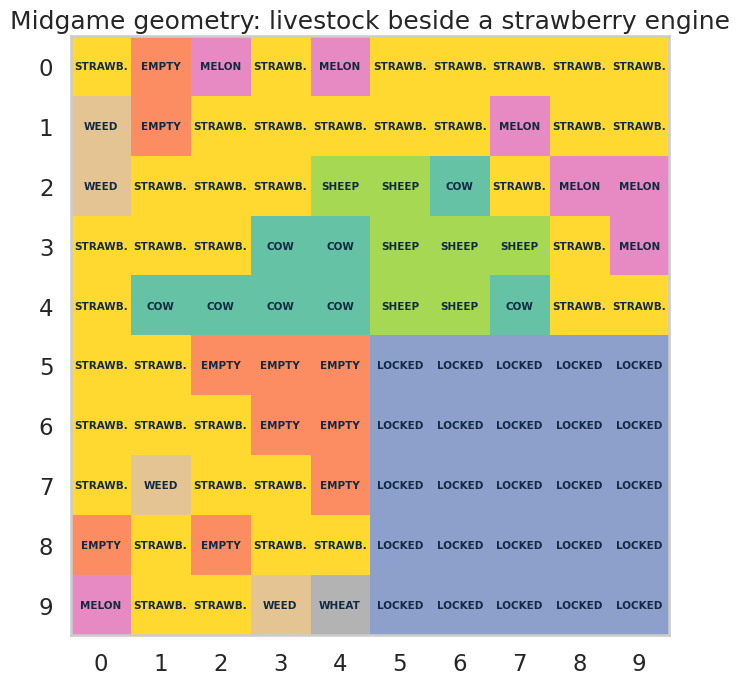

In [10]:
GEOMETRY = [['STRAWBERRY', 'EMPTY', 'MELON', 'STRAWBERRY', 'MELON', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY'], ['WEED', 'EMPTY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'MELON', 'STRAWBERRY', 'STRAWBERRY'], ['WEED', 'STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'SHEEP', 'SHEEP', 'COW', 'STRAWBERRY', 'MELON', 'MELON'], ['STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'COW', 'COW', 'SHEEP', 'SHEEP', 'SHEEP', 'STRAWBERRY', 'MELON'], ['STRAWBERRY', 'COW', 'COW', 'COW', 'COW', 'SHEEP', 'SHEEP', 'COW', 'STRAWBERRY', 'STRAWBERRY'], ['STRAWBERRY', 'STRAWBERRY', 'EMPTY', 'EMPTY', 'EMPTY', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'], ['STRAWBERRY', 'STRAWBERRY', 'STRAWBERRY', 'EMPTY', 'EMPTY', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'], ['STRAWBERRY', 'WEED', 'STRAWBERRY', 'STRAWBERRY', 'EMPTY', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'], ['EMPTY', 'STRAWBERRY', 'EMPTY', 'STRAWBERRY', 'STRAWBERRY', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED'], ['MELON', 'STRAWBERRY', 'STRAWBERRY', 'WEED', 'WHEAT', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED', 'LOCKED']]
labels = np.array(GEOMETRY)
categories = sorted(set(labels.ravel()))
palette = {name: i for i, name in enumerate(categories)}
grid = np.vectorize(palette.get)(labels)
fig, ax = plt.subplots(figsize=(9, 7.2))
cmap = sns.color_palette("Set2", n_colors=max(3, len(categories)), as_cmap=True)
ax.imshow(grid, cmap=cmap, vmin=0, vmax=max(1, len(categories)-1))
for y in range(labels.shape[0]):
    for x in range(labels.shape[1]):
        text = labels[y, x].replace("STRAWBERRY", "STRAWB.")
        ax.text(x, y, text, ha="center", va="center", fontsize=7.5, color="#102a43", fontweight="bold")
ax.set(title="Midgame geometry: livestock beside a strawberry engine", xticks=range(10), yticks=range(10))
ax.grid(False); plt.tight_layout(); plt.show()


## 4. Untouched-seed promotion gate

The candidate below was frozen before this larger matrix. Each pairing uses complete 720-turn games from both player positions. Opponents include strong public notebooks, prior versions, fixed portfolio counters, and freshly downloaded public agents. The heatmaps expose failures instead of hiding them behind one aggregate.


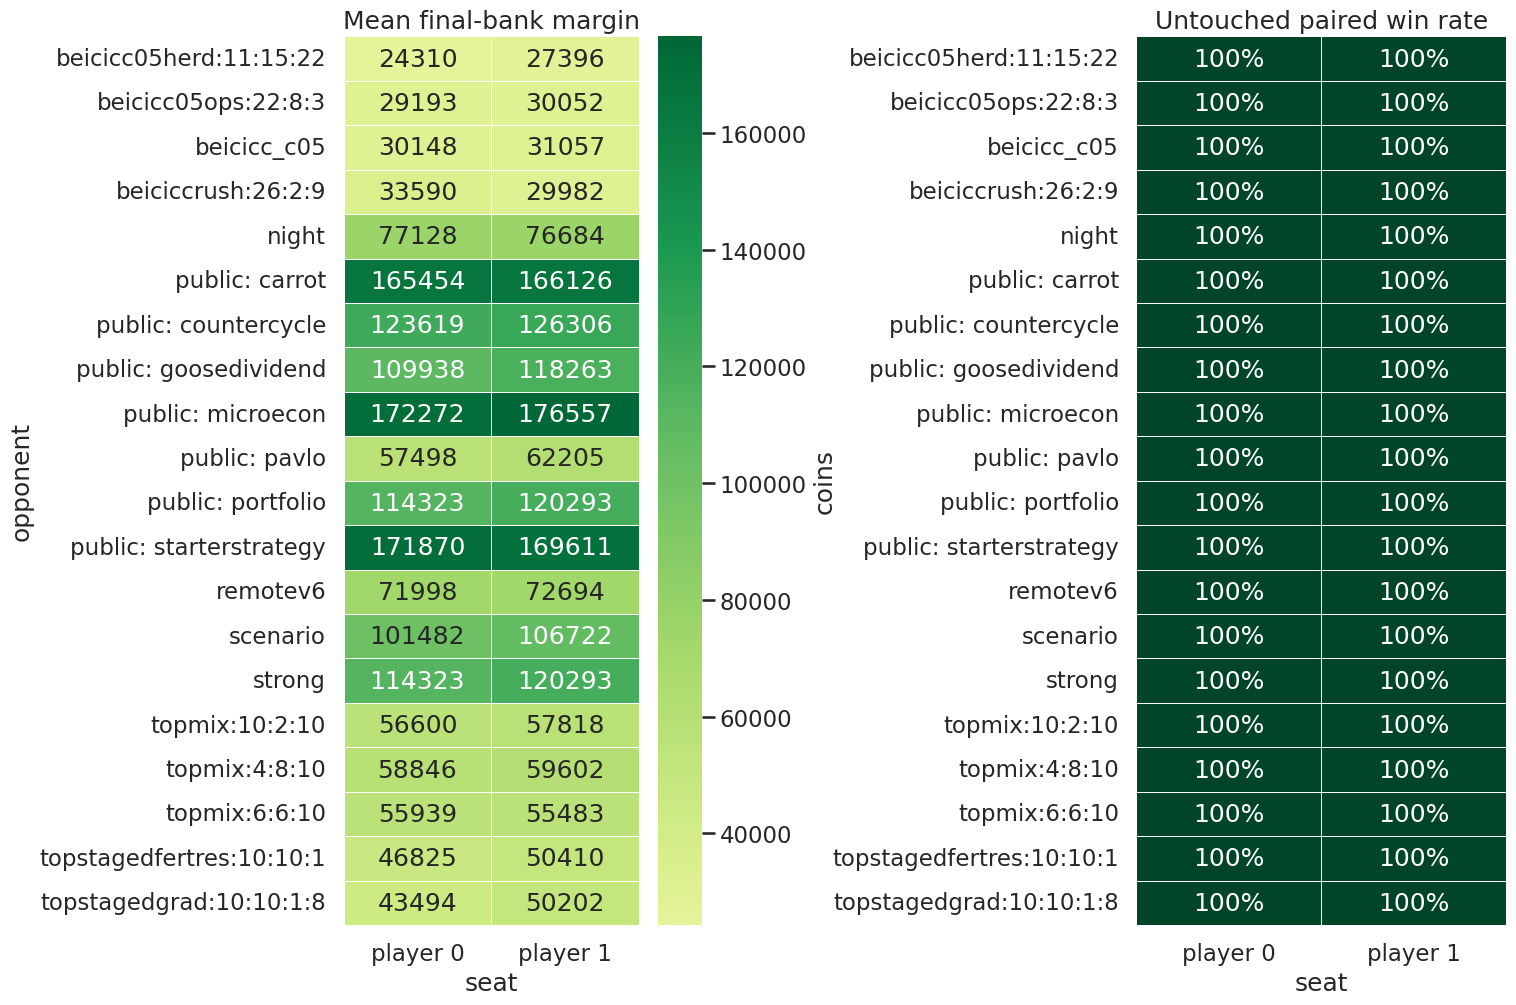

{'games': 320, 'wins': 320, 'win_rate': 1.0, 'mean_money': 150710.196875, 'mean_margin': 84165.128125, 'minimum_margin': 14454.0, 'all_done': True}


,opponent,side,games,wins,win_rate,mean_margin,min_margin,mean_money,all_done,opponent_label
17,refresh_microecon,1,8,8,1.0,176556.62,170435.0,176636.62,True,public: microecon
16,refresh_microecon,0,8,8,1.0,172271.88,166444.0,172351.88,True,public: microecon
22,refresh_starterstrategy,0,8,8,1.0,171870.12,158003.0,173860.12,True,public: starterstrategy
23,refresh_starterstrategy,1,8,8,1.0,169610.62,159410.0,171596.00,True,public: starterstrategy
11,refresh_carrot,1,8,8,1.0,166126.12,154961.0,173013.50,True,public: carrot
10,refresh_carrot,0,8,8,1.0,165454.50,158625.0,172253.62,True,public: carrot
13,refresh_countercycle,1,8,8,1.0,126306.38,112647.0,164270.75,True,public: countercycle
12,refresh_countercycle,0,8,8,1.0,123618.88,96608.0,160482.88,True,public: countercycle
21,refresh_portfolio,1,8,8,1.0,120292.75,110381.0,162150.25,True,public: portfolio
29,strong,1,8,8,1.0,120292.75,110381.0,162150.25,True,strong


In [11]:
BENCHMARK_SUMMARY_ROWS = [{'opponent': 'beicicc05herd:11:15:22', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 24309.5, 'min_margin': 14969.0, 'mean_money': 129723.625, 'all_done': True}, {'opponent': 'beicicc05herd:11:15:22', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 27396.5, 'min_margin': 16921.0, 'mean_money': 136241.875, 'all_done': True}, {'opponent': 'beicicc05ops:22:8:3', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 29192.875, 'min_margin': 14628.0, 'mean_money': 137507.75, 'all_done': True}, {'opponent': 'beicicc05ops:22:8:3', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 30052.25, 'min_margin': 14628.0, 'mean_money': 137078.375, 'all_done': True}, {'opponent': 'beicicc_c05', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 30147.5, 'min_margin': 16189.0, 'mean_money': 137515.25, 'all_done': True}, {'opponent': 'beicicc_c05', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 31057.0, 'min_margin': 16189.0, 'mean_money': 137081.5, 'all_done': True}, {'opponent': 'beiciccrush:26:2:9', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 33589.75, 'min_margin': 21152.0, 'mean_money': 139285.25, 'all_done': True}, {'opponent': 'beiciccrush:26:2:9', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 29982.0, 'min_margin': 14454.0, 'mean_money': 137558.5, 'all_done': True}, {'opponent': 'night', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 77127.875, 'min_margin': 65340.0, 'mean_money': 148765.875, 'all_done': True}, {'opponent': 'night', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 76684.375, 'min_margin': 67559.0, 'mean_money': 145686.5, 'all_done': True}, {'opponent': 'refresh_carrot', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 165454.5, 'min_margin': 158625.0, 'mean_money': 172253.625, 'all_done': True}, {'opponent': 'refresh_carrot', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 166126.125, 'min_margin': 154961.0, 'mean_money': 173013.5, 'all_done': True}, {'opponent': 'refresh_countercycle', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 123618.875, 'min_margin': 96608.0, 'mean_money': 160482.875, 'all_done': True}, {'opponent': 'refresh_countercycle', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 126306.375, 'min_margin': 112647.0, 'mean_money': 164270.75, 'all_done': True}, {'opponent': 'refresh_goosedividend', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 109938.25, 'min_margin': 104565.0, 'mean_money': 161822.125, 'all_done': True}, {'opponent': 'refresh_goosedividend', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 118262.75, 'min_margin': 104683.0, 'mean_money': 170163.25, 'all_done': True}, {'opponent': 'refresh_microecon', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 172271.875, 'min_margin': 166444.0, 'mean_money': 172351.875, 'all_done': True}, {'opponent': 'refresh_microecon', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 176556.625, 'min_margin': 170435.0, 'mean_money': 176636.625, 'all_done': True}, {'opponent': 'refresh_pavlo', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 57497.875, 'min_margin': 48589.0, 'mean_money': 147794.625, 'all_done': True}, {'opponent': 'refresh_pavlo', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 62205.125, 'min_margin': 54926.0, 'mean_money': 152142.25, 'all_done': True}, {'opponent': 'refresh_portfolio', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 114322.875, 'min_margin': 97294.0, 'mean_money': 155951.75, 'all_done': True}, {'opponent': 'refresh_portfolio', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 120292.75, 'min_margin': 110381.0, 'mean_money': 162150.25, 'all_done': True}, {'opponent': 'refresh_starterstrategy', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 171870.125, 'min_margin': 158003.0, 'mean_money': 173860.125, 'all_done': True}, {'opponent': 'refresh_starterstrategy', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 169610.625, 'min_margin': 159410.0, 'mean_money': 171596.0, 'all_done': True}, {'opponent': 'remotev6', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 71998.375, 'min_margin': 54072.0, 'mean_money': 152134.75, 'all_done': True}, {'opponent': 'remotev6', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 72694.125, 'min_margin': 57910.0, 'mean_money': 143586.5, 'all_done': True}, {'opponent': 'scenario', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 101481.5, 'min_margin': 89436.0, 'mean_money': 153921.625, 'all_done': True}, {'opponent': 'scenario', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 106722.375, 'min_margin': 90524.0, 'mean_money': 158511.0, 'all_done': True}, {'opponent': 'strong', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 114322.875, 'min_margin': 97294.0, 'mean_money': 155951.75, 'all_done': True}, {'opponent': 'strong', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 120292.75, 'min_margin': 110381.0, 'mean_money': 162150.25, 'all_done': True}, {'opponent': 'topmix:10:2:10', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 56600.375, 'min_margin': 41927.0, 'mean_money': 134792.75, 'all_done': True}, {'opponent': 'topmix:10:2:10', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 57817.875, 'min_margin': 46217.0, 'mean_money': 134205.625, 'all_done': True}, {'opponent': 'topmix:4:8:10', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 58846.0, 'min_margin': 51755.0, 'mean_money': 140367.0, 'all_done': True}, {'opponent': 'topmix:4:8:10', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 59602.25, 'min_margin': 46670.0, 'mean_money': 141654.125, 'all_done': True}, {'opponent': 'topmix:6:6:10', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 55939.375, 'min_margin': 46024.0, 'mean_money': 136637.0, 'all_done': True}, {'opponent': 'topmix:6:6:10', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 55482.75, 'min_margin': 36933.0, 'mean_money': 138900.875, 'all_done': True}, {'opponent': 'topstagedfertres:10:10:1', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 46825.0, 'min_margin': 29562.0, 'mean_money': 140077.0, 'all_done': True}, {'opponent': 'topstagedfertres:10:10:1', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 50409.625, 'min_margin': 32415.0, 'mean_money': 140189.0, 'all_done': True}, {'opponent': 'topstagedgrad:10:10:1:8', 'side': 0, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 43493.75, 'min_margin': 30940.0, 'mean_money': 147824.5, 'all_done': True}, {'opponent': 'topstagedgrad:10:10:1:8', 'side': 1, 'games': 8, 'wins': 8, 'win_rate': 1.0, 'mean_margin': 50201.75, 'min_margin': 38889.0, 'mean_money': 146570.0, 'all_done': True}]
grouped = pd.DataFrame(BENCHMARK_SUMMARY_ROWS)
grouped["opponent_label"] = grouped.opponent.str.replace("refresh_", "public: ", regex=False)
margin_heat = grouped.pivot(index="opponent_label", columns="side", values="mean_margin").rename(columns={0:"player 0",1:"player 1"})
win_heat = grouped.pivot(index="opponent_label", columns="side", values="win_rate").rename(columns={0:"player 0",1:"player 1"})
fig, axes = plt.subplots(1, 2, figsize=(15.5, max(7, .52*len(margin_heat))))
sns.heatmap(margin_heat, annot=True, fmt=".0f", center=0, cmap="RdYlGn", linewidths=.5, ax=axes[0], cbar_kws={"label":"coins"})
axes[0].set(title="Mean final-bank margin", xlabel="seat", ylabel="opponent")
sns.heatmap(win_heat, annot=True, fmt=".0%", vmin=0, vmax=1, cmap="YlGn", linewidths=.5, ax=axes[1], cbar=False)
axes[1].set(title="Untouched paired win rate", xlabel="seat", ylabel="")
plt.tight_layout(); plt.show()
gate = {
    "games": int(grouped.games.sum()), "wins": int(grouped.wins.sum()),
    "win_rate": float(grouped.wins.sum() / grouped.games.sum()),
    "mean_money": float(np.average(grouped.mean_money, weights=grouped.games)),
    "mean_margin": float(np.average(grouped.mean_margin, weights=grouped.games)),
    "minimum_margin": float(grouped.min_margin.min()), "all_done": bool(grouped.all_done.all()),
}
print(gate)
display(grouped.sort_values(["win_rate", "mean_margin"], ascending=False).round(2))


## 5. Write the distilled agent

The policy below is deliberately inspectable: one action dictionary for each observation step, selected with a bounds-safe index and deep-copied before return. It has no internet, replay-file, dataset, model, or notebook-global dependency at inference time.

**Attribution:** the behavioral tape is derived from the publicly downloadable action sequence of [Kaito Fukami](https://www.kaggle.com/kaitofukami), episode **89454731**. The routing rule, packaging, robustness tests, visual analysis, and presentation here are this notebook's contribution. Do not describe the underlying behavior as independently authored source code.


In [12]:
AGENT_SOURCE = '"""Fixed public Kaito Fukami policy from episode 89454731, seat 0."""\nimport copy\n\nTRACE_ACTIONS = [{\'farmer\': [\'PASS\'], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 3], [\'BUY_SEED\', \'MELON\', 6]]}, {\'farmer\': [\'BUILD_PASTURE\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'BUY_ANIMAL\', \'SHEEP\', 1]]}, {\'farmer\': [\'PICKUP\', \'COW\', 1], \'hands\': [[\'PICKUP\', \'SHEEP\', 1], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\']]}, {\'farmer\': [\'PLACE\', \'COW\'], \'hands\': [[\'WEST\'], [\'BUILD_PASTURE\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'BUILD_PASTURE\'], [\'NORTH\'], [\'SOUTH\'], [\'PICKUP\', \'COW\', 1]], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'BUILD_PASTURE\'], [\'PICKUP\', \'COW\', 1], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'PLACE\', \'COW\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'PLACE\', \'SHEEP\'], [\'PLANT\', \'MELON\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'PICKUP\', \'WHEAT\', 2]], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'NORTH\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'FEED\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLANT\', \'MELON\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'NORTH\'], [\'PLANT\', \'MELON\'], [\'SOUTH\'], [\'PLACE\', \'COW\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'FEED\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'PLANT\', \'MELON\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'CARE\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'DROP\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'SOUTH\'], [\'DROP\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'BUY_SEED\', \'MELON\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PLANT\', \'MELON\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'FERTILIZER\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'DROP\'], [\'NORTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'PASS\']], \'market\': [[\'BUY_SEED\', \'MELON\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'WEST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'PLANT\', \'MELON\'], [\'PASS\'], [\'WATER\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'WEST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'DROP\'], [\'NORTH\'], [\'PASS\'], [\'WEST\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'WEST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'DROP\'], [\'PASS\'], [\'EAST\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'PASS\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'NORTH\'], [\'DROP\'], [\'WEST\'], [\'NORTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'PASS\']], \'market\': [[\'BUY_SEED\', \'MELON\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WEST\'], [\'WEST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WEST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'PLANT\', \'MELON\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'NORTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'PLANT\', \'MELON\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'DROP\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'NORTH\'], [\'DROP\'], [\'NORTH\'], [\'NORTH\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'WEST\'], [\'WEST\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'DIG\'], [\'PASS\'], [\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'CARE\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'NORTH\'], [\'DROP\'], [\'PLANT\', \'STRAWBERRY\'], [\'NORTH\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WEST\'], [\'WEST\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WEST\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'NORTH\'], [\'WATER\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WEST\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WEST\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'DROP\'], [\'EAST\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'FERTILIZER\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'DROP\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'PASS\'], [\'EAST\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PASS\'], [\'DROP\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'WOOL\', 6]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'PASS\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_ANIMAL\', \'COW\', 2], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'BUILD_PASTURE\'], [\'BUILD_PASTURE\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'COW\', 2], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PLACE\', \'COW\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'CARE\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 3], [\'SELL\', \'WHEAT\', 6], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'COW\', 1], [\'CARE\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'DROP\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WEST\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PLACE\', \'COW\'], [\'WATER\'], [\'NORTH\'], [\'PASS\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'CARE\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'PICKUP\', \'WHEAT\', 1], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'DROP\'], [\'WEST\'], [\'WATER\'], [\'FEED\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PASS\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PASS\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'PASS\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 6], [\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'DROP\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MILK\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_ANIMAL\', \'SHEEP\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'HARVEST\'], [\'CARE\'], [\'SOUTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\']]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'DROP\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'DROP\'], [\'CARE\'], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 6]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_LAND\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_ANIMAL\', \'SHEEP\', 2], [\'BUY_SEED\', \'STRAWBERRY\', 5]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'BUILD_PASTURE\'], [\'BUILD_PASTURE\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'BUILD_PASTURE\'], [\'PICKUP\', \'SHEEP\', 2], [\'WATER\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'BUILD_PASTURE\'], [\'NORTH\'], [\'PICKUP\', \'SHEEP\', 1], [\'NORTH\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'PICKUP\', \'SHEEP\', 1], [\'WATER\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'NORTH\'], [\'PLACE\', \'SHEEP\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'NORTH\'], [\'PLACE\', \'SHEEP\'], [\'WATER\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'EAST\'], [\'CARE\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'SOUTH\'], [\'PLACE\', \'SHEEP\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'CARE\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'DROP\'], [\'WATER\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'SHEEP\', 1], [\'CARE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'CARE\'], [\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'PLACE\', \'SHEEP\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'SOUTH\'], [\'PICKUP\', \'WHEAT\', 1], [\'CARE\'], [\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'DROP\'], [\'NORTH\'], [\'PASS\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'PASS\'], [\'FEED\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'PASS\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'PASS\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'SOUTH\'], [\'PASS\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'PASS\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'PASS\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'DROP\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'WEST\'], [\'DROP\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'FERTILIZER\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 8], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'HARVEST\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'FEED\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'PICKUP\', \'WHEAT\', 2], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'FEED\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'EAST\'], [\'HARVEST\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'DROP\'], [\'EAST\']], \'market\': [[\'SELL\', \'MILK\', 3], [\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'DROP\']], \'market\': [[\'SELL\', \'MELON\', 6]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'NORTH\'], [\'PASS\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'DROP\'], [\'WEST\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'SELL\', \'MILK\', 3], [\'BUY_ANIMAL\', \'COW\', 3], [\'BUY_SEED\', \'MELON\', 5]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'PASS\'], [\'PLANT\', \'MELON\'], [\'EAST\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'BUY_ANIMAL\', \'SHEEP\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'BUY_SEED\', \'MELON\', 1]]}, {\'farmer\': [\'BUILD_PASTURE\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'BUILD_PASTURE\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'PLANT\', \'MELON\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'BUILD_PASTURE\'], \'hands\': [[\'BUILD_PASTURE\'], [\'WEST\'], [\'DROP\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'BUILD_PASTURE\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'BUY_SEED\', \'MELON\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'PICKUP\', \'COW\', 3], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'PICKUP\', \'SHEEP\', 2]], \'market\': [[\'SELL\', \'FERTILIZER\', 8]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'MELON\', 18], [\'SELL\', \'WHEAT\', 15], [\'SELL\', \'MILK\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'COW\', 3], [\'NORTH\'], [\'PICKUP\', \'SHEEP\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'PLACE\', \'SHEEP\'], [\'NORTH\'], [\'WATER\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'CARE\'], [\'WATER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WATER\'], [\'FEED\'], [\'SOUTH\'], [\'PLACE\', \'COW\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WATER\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'PLANT\', \'MELON\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'WEST\'], [\'FEED\'], [\'FEED\'], [\'SOUTH\'], [\'PLANT\', \'MELON\'], [\'PLACE\', \'SHEEP\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'CARE\'], [\'DROP\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'FEED\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'PASS\'], [\'PLACE\', \'COW\'], [\'WEST\'], [\'PLANT\', \'MELON\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'CARE\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'PLANT\', \'MELON\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1], [\'BUY_LAND\']]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'PASS\'], [\'WEST\'], [\'PLANT\', \'MELON\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'DIG\'], [\'EAST\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'PASS\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'FEED\'], [\'PASS\'], [\'DROP\'], [\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'PICKUP\', \'COW\', 1], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'EAST\'], [\'DROP\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'FEED\'], [\'PASS\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 6], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 14], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'COW\', 1], [\'CARE\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'FEED\'], [\'SOUTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'WATER\'], [\'CARE\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'DIG\'], [\'CARE\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'PLANT\', \'STRAWBERRY\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'PLACE\', \'COW\'], [\'FEED\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'CARE\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'FEED\'], [\'FERTILIZE\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'WATER\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'NORTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'DROP\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'DROP\'], \'hands\': [[\'PASS\'], [\'WATER\'], [\'NORTH\'], [\'DROP\'], [\'WATER\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 3], [\'SELL\', \'WHEAT\', 7], [\'SELL\', \'FERTILIZER\', 8]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'MILK\', 6], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'FEED\'], [\'CARE\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'FEED\'], [\'WEST\'], [\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WATER\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'EAST\'], [\'CARE\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'FERTILIZE\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'FEED\'], [\'WEST\'], [\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'FEED\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'DROP\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'WATER\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'DROP\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'SOUTH\'], [\'DROP\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'WEST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'DIG\'], [\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'DIG\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'FERTILIZER\', 10], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'MELON\', 6], [\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'WHEAT\', 14], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'MELON\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'EAST\'], [\'HARVEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'EAST\'], [\'FEED\'], [\'CARE\'], [\'FEED\'], [\'WATER\'], [\'WEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'CARE\'], [\'CARE\'], [\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'WATER\'], [\'CARE\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'EAST\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'EAST\'], [\'FEED\'], [\'CARE\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WATER\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'WATER\'], [\'DROP\'], [\'NORTH\'], [\'DROP\'], [\'CARE\']], \'market\': [[\'SELL\', \'MILK\', 9], [\'SELL\', \'WOOL\', 5]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'CARE\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'DROP\'], [\'HARVEST\'], [\'EAST\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'DROP\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'DROP\'], [\'NORTH\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'SELL\', \'WOOL\', 6], [\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'EAST\'], [\'DROP\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'MILK\', 6], [\'SELL\', \'FERTILIZER\', 5], [\'BUY_SEED\', \'WHEAT\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'DROP\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 5]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WOOL\', 6], [\'SELL\', \'WHEAT\', 15], [\'SELL\', \'STRAWBERRY\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'PICKUP\', \'WHEAT\', 2], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'FEED\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WATER\'], [\'FEED\'], [\'FEED\'], [\'FEED\'], [\'WATER\'], [\'FEED\'], [\'WATER\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'PLANT\', \'WHEAT\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'EAST\'], [\'FEED\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WATER\'], [\'FEED\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'WEST\'], [\'FEED\'], [\'WATER\'], [\'HARVEST\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\'], [\'EAST\'], [\'EAST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'HARVEST\'], [\'FEED\'], [\'WATER\'], [\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'DIG\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'PLANT\', \'STRAWBERRY\'], [\'CARE\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'PLANT\', \'WHEAT\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'HARVEST\'], [\'FEED\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'WATER\'], [\'CARE\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'PLANT\', \'MELON\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'CARE\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'PASS\'], [\'WEST\'], [\'DIG\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'DROP\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'PASS\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 6], [\'SELL\', \'FERTILIZER\', 10], [\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WOOL\', 10], [\'SELL\', \'FERTILIZER\', 4], [\'SELL\', \'STRAWBERRY\', 8], [\'SELL\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'HARVEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'FEED\'], [\'FEED\'], [\'CARE\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'CARE\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'CARE\'], [\'WATER\'], [\'NORTH\'], [\'PLANT\', \'WHEAT\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'FEED\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'CARE\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'FEED\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FERTILIZE\'], [\'WEST\'], [\'WATER\'], [\'DROP\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'MILK\', 6], [\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WEST\'], [\'PASS\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'PASS\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'SELL\', \'FERTILIZER\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'MILK\', 6], [\'SELL\', \'FERTILIZER\', 3], [\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'WHEAT\', 14], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'NORTH\'], [\'FEED\'], [\'HARVEST\'], [\'FEED\'], [\'WATER\'], [\'CARE\'], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'FEED\'], [\'EAST\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'SOUTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'EAST\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'FEED\'], [\'WATER\'], [\'FERTILIZE\'], [\'WATER\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WATER\'], [\'FERTILIZE\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'FEED\'], [\'FERTILIZE\'], [\'NORTH\'], [\'WATER\'], [\'CARE\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'FERTILIZE\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'FERTILIZE\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'DROP\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 6]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'CARE\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'DROP\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'DROP\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'WEST\'], [\'WATER\']], \'market\': [[\'SELL\', \'FERTILIZER\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WOOL\', 18], [\'SELL\', \'MILK\', 3], [\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'EAST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'HARVEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'EAST\'], [\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'FEED\'], [\'CARE\'], [\'FEED\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'HARVEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'FEED\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WATER\'], [\'FEED\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'CARE\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'FEED\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'SOUTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'DROP\'], [\'FERTILIZE\'], [\'WATER\'], [\'WATER\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'FERTILIZE\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'MILK\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FERTILIZE\'], [\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'HARVEST\'], [\'WATER\'], [\'WATER\'], [\'FERTILIZE\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'DROP\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'MILK\', 3], [\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'FERTILIZER\', 8]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'STRAWBERRY\', 10], [\'SELL\', \'MILK\', 3], [\'SELL\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'CARE\'], [\'FEED\'], [\'CARE\'], [\'HARVEST\'], [\'SOUTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'CARE\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FERTILIZE\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'HARVEST\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WATER\'], [\'WEST\'], [\'FEED\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'CARE\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'EAST\'], [\'DROP\'], [\'NORTH\'], [\'EAST\'], [\'DROP\']], \'market\': [[\'SELL\', \'MILK\', 12]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'FERTILIZE\'], [\'FEED\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'DROP\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'WEST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 6]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 12], [\'SELL\', \'MILK\', 3], [\'SELL\', \'WHEAT\', 18], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'HARVEST\'], [\'CARE\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'FEED\'], [\'WATER\'], [\'CARE\'], [\'WATER\'], [\'CARE\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'HARVEST\'], [\'HARVEST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'EAST\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'HARVEST\'], [\'FEED\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'FERTILIZE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'FERTILIZE\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'DIG\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'FEED\'], [\'NORTH\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'EAST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'FEED\'], [\'DROP\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'WATER\']], \'market\': [[\'SELL\', \'MILK\', 12], [\'SELL\', \'FERTILIZER\', 4]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'DROP\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WATER\'], [\'PASS\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 7]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WOOL\', 20], [\'SELL\', \'MELON\', 12], [\'SELL\', \'MILK\', 6], [\'SELL\', \'STRAWBERRY\', 12], [\'SELL\', \'WHEAT\', 14], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'PICKUP\', \'FERTILIZER\', 3], [\'PICKUP\', \'FERTILIZER\', 3], [\'PICKUP\', \'FERTILIZER\', 1], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'FEED\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'FEED\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'WEST\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'FEED\'], [\'FERTILIZE\'], [\'CARE\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'EAST\'], [\'HARVEST\'], [\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'DIG\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'EAST\'], [\'HARVEST\'], [\'DIG\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'FERTILIZE\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FERTILIZE\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'FERTILIZE\'], [\'WEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'HARVEST\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'FERTILIZE\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'FERTILIZE\'], [\'DROP\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'DROP\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MELON\', 12], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'WEST\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'WATER\'], [\'PASS\'], [\'HARVEST\'], [\'DIG\'], [\'NORTH\'], [\'PASS\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'PASS\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'MELON\', 18], [\'SELL\', \'MILK\', 9], [\'SELL\', \'STRAWBERRY\', 12], [\'SELL\', \'FERTILIZER\', 3], [\'SELL\', \'WHEAT\', 11], [\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 11], [\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'PICKUP\', \'FERTILIZER\', 3], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'FEED\'], [\'CARE\'], [\'HARVEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'FEED\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'CARE\'], [\'DIG\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'HARVEST\'], [\'CARE\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'FEED\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'FEED\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'HARVEST\'], [\'EAST\'], [\'CARE\'], [\'WEST\'], [\'WATER\'], [\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'FEED\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'FERTILIZE\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FERTILIZE\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'FERTILIZE\'], [\'NORTH\'], [\'DROP\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'DIG\'], [\'EAST\'], [\'HARVEST\'], [\'HARVEST\'], [\'NORTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'FERTILIZE\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'PASS\'], [\'HARVEST\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'DIG\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'MILK\', 15], [\'SELL\', \'STRAWBERRY\', 24], [\'SELL\', \'FERTILIZER\', 7], [\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'CARE\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'CARE\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'DIG\'], [\'WATER\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'CARE\'], [\'FEED\'], [\'SOUTH\'], [\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'FERTILIZE\'], [\'CARE\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'EAST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'FEED\'], [\'DROP\'], [\'HARVEST\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'WOOL\', 5], [\'SELL\', \'WOOL\', 3]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'FERTILIZE\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'FERTILIZE\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'WEST\'], [\'EAST\'], [\'HARVEST\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'HARVEST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'EAST\'], [\'DROP\']], \'market\': [[\'SELL\', \'MILK\', 3], [\'SELL\', \'WOOL\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'FERTILIZE\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'HARVEST\'], [\'PASS\']], \'market\': [[\'SELL\', \'WOOL\', 3]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'DIG\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FERTILIZE\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'PASS\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 7]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 19], [\'SELL\', \'MILK\', 6], [\'SELL\', \'WOOL\', 8], [\'SELL\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'PICKUP\', \'FERTILIZER\', 3], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'FEED\'], [\'CARE\'], [\'HARVEST\'], [\'WATER\'], [\'CARE\'], [\'WATER\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'FEED\'], [\'HARVEST\'], [\'FEED\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'DIG\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'FEED\'], [\'CARE\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'CARE\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'FEED\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'HARVEST\'], [\'WEST\'], [\'DROP\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 6], [\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'HARVEST\'], [\'WEST\'], [\'PASS\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'DROP\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'DROP\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 5], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'DROP\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 12]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'FERTILIZE\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'DROP\'], [\'PASS\'], [\'DROP\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'STRAWBERRY\', 5], [\'SELL\', \'MILK\', 3], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 15], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'MILK\', 6], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 7]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'CARE\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'EAST\'], [\'EAST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'EAST\'], [\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'CARE\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'SOUTH\'], [\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'CARE\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\'], [\'FERTILIZE\']], \'market\': [[\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'FEED\'], [\'EAST\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'EAST\'], [\'FEED\'], [\'CARE\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'DIG\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'FERTILIZE\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'FERTILIZE\'], \'hands\': [[\'FEED\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'DIG\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'DROP\'], [\'SOUTH\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'FERTILIZE\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'FERTILIZE\'], [\'DIG\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'DROP\']], \'market\': [[\'SELL\', \'MILK\', 3], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'WATER\'], [\'DROP\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 5], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'PASS\'], [\'NORTH\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 7], [\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 24], [\'SELL\', \'MILK\', 6], [\'SELL\', \'WHEAT\', 14], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'CARE\'], [\'FEED\'], [\'CARE\'], [\'EAST\'], [\'HARVEST\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'CARE\'], [\'FEED\'], [\'CARE\'], [\'CARE\'], [\'HARVEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'FEED\'], [\'SOUTH\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'EAST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'HARVEST\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'EAST\'], [\'SOUTH\'], [\'CARE\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'DROP\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'WATER\']], \'market\': [[\'SELL\', \'WOOL\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'FEED\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'CARE\'], [\'HARVEST\'], [\'CARE\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'WEST\'], [\'FERTILIZE\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'DIG\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'FERTILIZE\'], [\'NORTH\'], [\'SOUTH\'], [\'DROP\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WATER\']], \'market\': [[\'SELL\', \'WOOL\', 8]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'NORTH\'], [\'DIG\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'DIG\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'DROP\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'EAST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'DROP\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'MILK\', 3], [\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'DROP\'], [\'DROP\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 12], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 10]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 18], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'EAST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'HARVEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'FEED\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'HARVEST\'], [\'CARE\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'HARVEST\'], [\'CARE\'], [\'SOUTH\'], [\'DIG\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'CARE\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'FERTILIZE\'], [\'WEST\'], [\'CARE\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'FEED\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'DIG\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'FEED\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'DROP\'], [\'FEED\'], [\'FERTILIZE\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'DIG\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PASS\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'DIG\'], [\'WATER\'], [\'WATER\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'DIG\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PASS\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'DROP\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 10]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'MILK\', 6], [\'SELL\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 13], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'DROP\'], [\'SOUTH\'], [\'HARVEST\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 6]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'HARVEST\'], [\'DIG\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'HARVEST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'FEED\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'DIG\'], [\'COLLECT_FERTILIZER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'WEST\'], [\'NORTH\'], [\'DIG\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FERTILIZE\'], [\'FEED\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'DIG\'], [\'WEST\'], [\'DROP\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'DIG\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'CARE\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FERTILIZE\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'DROP\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\']], \'market\': [[\'SELL\', \'MILK\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'FERTILIZE\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'WATER\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'NORTH\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'DROP\'], [\'PASS\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 10]]}, {\'farmer\': [\'EAST\'], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 16], [\'SELL\', \'MILK\', 4], [\'SELL\', \'FERTILIZER\', 5], [\'SELL\', \'WHEAT\', 34], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'EAST\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'DROP\'], [\'WEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 4]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'DROP\'], [\'WEST\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PASS\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'PASS\'], [\'HARVEST\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'DROP\'], \'hands\': [[\'PASS\'], [\'NORTH\'], [\'DROP\'], [\'SOUTH\'], [\'PASS\'], [\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 16], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'NORTH\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'DROP\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 5]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'EAST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'DROP\'], [\'PASS\'], [\'DROP\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'DROP\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 9], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}]\n\n\ndef agent(obs, config=None):\n    step = min(int(obs.get("step", 0) or 0), len(TRACE_ACTIONS) - 1)\n    return copy.deepcopy(TRACE_ACTIONS[step])\n'
MAIN_PATH = Path("/kaggle/working/main.py") if Path("/kaggle/working").exists() else Path("main.py")
MAIN_PATH.write_text(AGENT_SOURCE, encoding="utf-8")
compile(AGENT_SOURCE, str(MAIN_PATH), "exec")
print({"path": str(MAIN_PATH), "lines": len(AGENT_SOURCE.splitlines()), "bytes": MAIN_PATH.stat().st_size,
       "source_sha256": hashlib.sha256(MAIN_PATH.read_bytes()).hexdigest()})


{'path': '/kaggle/working/main.py', 'lines': 9, 'bytes': 136061, 'source_sha256': '32ce3d57a994edfc5856383da074a059cad4117e7ea84012398316f68aad048e'}


### Live execution proof

This is not a mock: the cell reloads the written file and runs complete official-simulator episodes from both positions. The notebook fails if either side does not reach `DONE`.


In [13]:
live_rows, representative = [], None
for side in (0, 1):
    agents = [str(MAIN_PATH), "starter"] if side == 0 else ["starter", str(MAIN_PATH)]
    env = make("kaggriculture", configuration={"episodeSteps": 720, "seed": 424242}, debug=False)
    env.run(agents)
    final = env.steps[-1]
    live_rows.append({
        "side": side, "agent_money": float(final[side].reward),
        "opponent_money": float(final[1-side].reward), "status": str(final[side].status),
        "opponent_status": str(final[1-side].status),
    })
    if side == 0: representative = env
live = pd.DataFrame(live_rows)
live["margin"] = live.agent_money - live.opponent_money
assert ((live.status == "DONE") & (live.opponent_status == "DONE")).all()
display(live)
print({"games": len(live), "wins": int((live.margin > 0).sum()), "mean_money": float(live.agent_money.mean())})


,side,agent_money,opponent_money,status,opponent_status,margin
0,0,184361.0,3495.0,DONE,DONE,180866.0
1,1,182951.0,3495.0,DONE,DONE,179456.0


{'games': 2, 'wins': 2, 'mean_money': 183656.0}


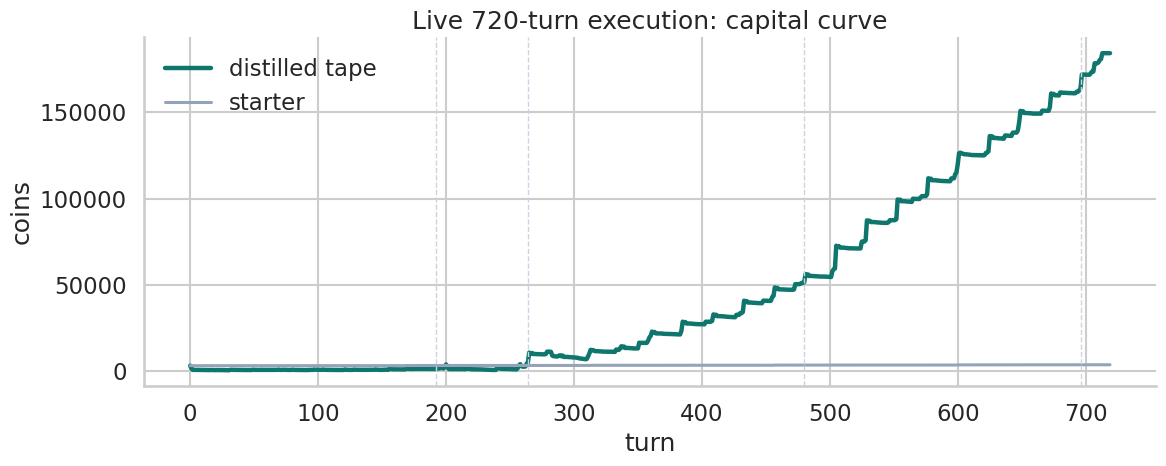

In [14]:
money_a = [float(step[0].observation.farms[0].money) for step in representative.steps]
money_b = [float(step[0].observation.farms[1].money) for step in representative.steps]
turns = np.arange(len(money_a))
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(turns, money_a, lw=3.2, color=COLORS[0], label="distilled tape")
ax.plot(turns, money_b, lw=2.2, color="#94a3b8", label="starter")
for day in (8, 11, 20, 29): ax.axvline(day*24, color="#cbd5e1", ls="--", lw=1)
ax.set(title="Live 720-turn execution: capital curve", xlabel="turn", ylabel="coins")
ax.legend(frameon=False); sns.despine(); plt.tight_layout(); plt.show()


## 6. Package integrity

The competition archive contains exactly one root file, `main.py`. Use this notebook version's **Submit to competition** button and choose `submission.tar.gz`.


In [15]:
ARCHIVE_PATH = MAIN_PATH.parent / "submission.tar.gz"
with tarfile.open(ARCHIVE_PATH, "w:gz") as archive:
    archive.add(MAIN_PATH, arcname="main.py")
with tarfile.open(ARCHIVE_PATH, "r:gz") as archive:
    assert archive.getnames() == ["main.py"]
print({"artifact": str(ARCHIVE_PATH), "bytes": ARCHIVE_PATH.stat().st_size,
       "sha256": hashlib.sha256(ARCHIVE_PATH.read_bytes()).hexdigest(), "members": ["main.py"]})


{'artifact': '/kaggle/working/submission.tar.gz', 'bytes': 9220, 'sha256': 'd6fc2302a69211928c09668dccfed0c58cf0ef84e3088003787241669e96c953', 'members': ['main.py']}


## Observed-ladder falsification and repair

Broad bot suites did not predict every top-band result, so this gate uses eight preserved public action traces and eight ladder seeds. The earlier seven Version 12 replays passed exact reward reproduction; the comparison below then crosses every candidate with every opponent trace in both seats.

This is deliberately a **stress test**, not a claim that the opponent would keep the same actions after our policy changes. Its value is comparative: the same replay mechanism is applied to Version 19, Version 16, and rank-one venks.


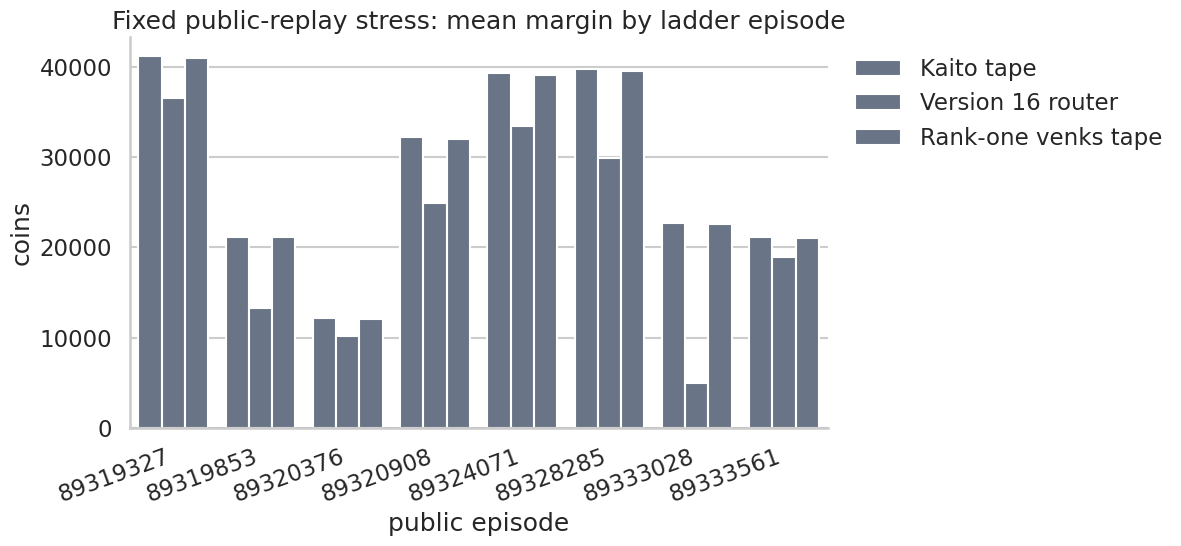

,variant,games,wins,win_rate,mean_margin,minimum_margin,mean_money
0,Kaito tape,128,126,0.98,28731.95,-16083.0,123598.91
1,Version 16 router,128,119,0.93,21530.55,-6399.0,120090.76
2,Rank-one venks tape,128,126,0.98,28569.38,-16083.0,123490.91


In [16]:
REPAIR_SUMMARY_ROWS = [{'candidate': 'newtoptrace:89454731:0', 'episode_id': 89319327, 'games': 16, 'wins': 16, 'mean_margin': 41244.875, 'minimum_margin': 18017.0, 'mean_money': 129929.375}, {'candidate': 'newtoptrace:89454731:0', 'episode_id': 89319853, 'games': 16, 'wins': 16, 'mean_margin': 21166.6875, 'minimum_margin': 2496.0, 'mean_money': 119017.75}, {'candidate': 'newtoptrace:89454731:0', 'episode_id': 89320376, 'games': 16, 'wins': 14, 'mean_margin': 12197.5, 'minimum_margin': -16083.0, 'mean_money': 111678.1875}, {'candidate': 'newtoptrace:89454731:0', 'episode_id': 89320908, 'games': 16, 'wins': 16, 'mean_margin': 32267.1875, 'minimum_margin': 22801.0, 'mean_money': 125037.0}, {'candidate': 'newtoptrace:89454731:0', 'episode_id': 89324071, 'games': 16, 'wins': 16, 'mean_margin': 39375.9375, 'minimum_margin': 23096.0, 'mean_money': 132882.875}, {'candidate': 'newtoptrace:89454731:0', 'episode_id': 89328285, 'games': 16, 'wins': 16, 'mean_margin': 39744.6875, 'minimum_margin': 12595.0, 'mean_money': 126798.8125}, {'candidate': 'newtoptrace:89454731:0', 'episode_id': 89333028, 'games': 16, 'wins': 16, 'mean_margin': 22693.75, 'minimum_margin': 15401.0, 'mean_money': 119316.125}, {'candidate': 'newtoptrace:89454731:0', 'episode_id': 89333561, 'games': 16, 'wins': 16, 'mean_margin': 21165.0, 'minimum_margin': 6763.0, 'mean_money': 124131.125}, {'candidate': 'radianttrace_router_v16', 'episode_id': 89319327, 'games': 16, 'wins': 16, 'mean_margin': 36579.5625, 'minimum_margin': 24586.0, 'mean_money': 131932.0625}, {'candidate': 'radianttrace_router_v16', 'episode_id': 89319853, 'games': 16, 'wins': 13, 'mean_margin': 13260.8125, 'minimum_margin': -6399.0, 'mean_money': 109120.375}, {'candidate': 'radianttrace_router_v16', 'episode_id': 89320376, 'games': 16, 'wins': 15, 'mean_margin': 10161.875, 'minimum_margin': -63.0, 'mean_money': 93571.8125}, {'candidate': 'radianttrace_router_v16', 'episode_id': 89320908, 'games': 16, 'wins': 16, 'mean_margin': 24927.5625, 'minimum_margin': 19913.0, 'mean_money': 127632.4375}, {'candidate': 'radianttrace_router_v16', 'episode_id': 89324071, 'games': 16, 'wins': 16, 'mean_margin': 33481.75, 'minimum_margin': 23081.0, 'mean_money': 132146.875}, {'candidate': 'radianttrace_router_v16', 'episode_id': 89328285, 'games': 16, 'wins': 16, 'mean_margin': 29895.625, 'minimum_margin': 13911.0, 'mean_money': 129159.4375}, {'candidate': 'radianttrace_router_v16', 'episode_id': 89333028, 'games': 16, 'wins': 11, 'mean_margin': 4976.5, 'minimum_margin': -3625.0, 'mean_money': 113196.0}, {'candidate': 'radianttrace_router_v16', 'episode_id': 89333561, 'games': 16, 'wins': 16, 'mean_margin': 18960.75, 'minimum_margin': 4803.0, 'mean_money': 123967.0625}, {'candidate': 'venkstrace:89454731', 'episode_id': 89319327, 'games': 16, 'wins': 16, 'mean_margin': 40966.4375, 'minimum_margin': 18017.0, 'mean_money': 129696.375}, {'candidate': 'venkstrace:89454731', 'episode_id': 89319853, 'games': 16, 'wins': 16, 'mean_margin': 21116.4375, 'minimum_margin': 2521.0, 'mean_money': 119000.0625}, {'candidate': 'venkstrace:89454731', 'episode_id': 89320376, 'games': 16, 'wins': 14, 'mean_margin': 12083.0, 'minimum_margin': -16083.0, 'mean_money': 111674.25}, {'candidate': 'venkstrace:89454731', 'episode_id': 89320908, 'games': 16, 'wins': 16, 'mean_margin': 32026.0, 'minimum_margin': 22799.0, 'mean_money': 124826.0625}, {'candidate': 'venkstrace:89454731', 'episode_id': 89324071, 'games': 16, 'wins': 16, 'mean_margin': 39095.375, 'minimum_margin': 22019.0, 'mean_money': 132659.9375}, {'candidate': 'venkstrace:89454731', 'episode_id': 89328285, 'games': 16, 'wins': 16, 'mean_margin': 39543.6875, 'minimum_margin': 12595.0, 'mean_money': 126644.875}, {'candidate': 'venkstrace:89454731', 'episode_id': 89333028, 'games': 16, 'wins': 16, 'mean_margin': 22630.25, 'minimum_margin': 15406.0, 'mean_money': 119355.25}, {'candidate': 'venkstrace:89454731', 'episode_id': 89333561, 'games': 16, 'wins': 16, 'mean_margin': 21093.8125, 'minimum_margin': 6768.0, 'mean_money': 124070.4375}]
repair = pd.DataFrame(REPAIR_SUMMARY_ROWS)
repair["variant"] = repair.candidate.map({'newtoptrace:89454731:0': 'Kaito tape', 'radianttrace_router_v16': 'Version 16 router', 'venkstrace:89454731': 'Rank-one venks tape'})
repair["episode"] = repair.episode_id.astype(str)
fig, ax = plt.subplots(figsize=(16.5, 5.8))
repair_palette = {'Kaito tape': '#64748b', 'Version 16 router': '#64748b', 'Rank-one venks tape': '#64748b'}
sns.barplot(data=repair, x="episode", y="mean_margin", hue="variant", palette=repair_palette, errorbar=None, ax=ax)
ax.axhline(0, color="#334155", lw=1)
ax.set(title="Fixed public-replay stress: mean margin by ladder episode", xlabel="public episode", ylabel="coins")
ax.tick_params(axis="x", labelrotation=20)
for label in ax.get_xticklabels(): label.set_horizontalalignment("right")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
sns.despine(); plt.tight_layout(rect=(0, 0, .74, 1)); plt.show()
repair_summary = pd.DataFrame([{'variant': 'Kaito tape', 'games': 128, 'wins': 126, 'win_rate': 0.984375, 'mean_margin': 28731.953125, 'minimum_margin': -16083.0, 'mean_money': 123598.90625}, {'variant': 'Version 16 router', 'games': 128, 'wins': 119, 'win_rate': 0.9296875, 'mean_margin': 21530.5546875, 'minimum_margin': -6399.0, 'mean_money': 120090.7578125}, {'variant': 'Rank-one venks tape', 'games': 128, 'wins': 126, 'win_rate': 0.984375, 'mean_margin': 28569.375, 'minimum_margin': -16083.0, 'mean_money': 123490.90625}])
display(repair_summary.round(2))


---

## Turn this starter into an adaptive frontier

1. **Behavior-clone by state, not step.** Use public replay observations and actions as supervised examples, then retrieve or predict actions from the current farm state.
2. **Add legality-aware repair.** When a taped action misses, redirect the freed hand to the highest-value nearby care, feed, harvest, water, or drop job.
3. **Condition the market block.** Preserve the tape's capital schedule but size buys and sells from live inventory, price, town demand, and rival exposure.
4. **Ensemble tapes.** Select a schedule by early weed pressure or opponent acreage instead of committing to one episode at step 0.
5. **Keep symmetric gates.** Shared-market ordering makes player position real; every promotion should use both seats and untouched seeds.

The key result is less mystical than it looks: a great Kaggriculture farm is a timed supply chain. This notebook makes one elite public trajectory executable, measurable, and easy to improve. If it saves you days of reverse engineering, an upvote helps other competitors find the evidence and the caveats. 🌾
